<a href="https://colab.research.google.com/github/bdashti/v/blob/main/2_5_Supervised_slow_superantileak_GPUdesktopoptimised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# @title Cell 0: Initial Dataset Input LOAD + Smart Auto-Resume
# =====================================================================
# Behaviour:
#   - RESUME = False (default): runs the normal CSV loading logic.
#   - RESUME = True: auto-detects the most recent checkpoint (3 > 2 > 1)
#     and loads ONLY that one. The save cells delete superseded
#     checkpoints, so under normal use only the latest checkpoint is on
#     disk anyway — but if multiple are present, the highest wins.
#
# After loading SP3: ready for Cell 25 (Oracle). Skip Cells 1-24.
# After loading SP2: ready for Cell 19 (base learner training).
# After loading SP1: ready for Cell 17 (Optuna CatBoost).

# ─── SWITCH ──────────────────────────────────────────────────────────────
RESUME = False     # set True to auto-resume from the latest checkpoint
# ─────────────────────────────────────────────────────────────────────────

import os
import joblib
import pandas as pd
import numpy as np

if RESUME:
    # ════════════════════════════════════════════════════════════════════
    # AUTO-DETECT AND LOAD HIGHEST-NUMBERED CHECKPOINT
    # ════════════════════════════════════════════════════════════════════
    print("=" * 64)
    print(" AUTO-RESUME: detecting highest available checkpoint")
    print("=" * 64)

    # Detect which checkpoint exists (highest wins, even if multiple present)
    if os.path.exists("checkpoints/sp3_metadata.pkl"):
        active_sp = 3
    elif os.path.exists("checkpoints/sp2_metadata.pkl"):
        active_sp = 2
    elif os.path.exists("checkpoints/sp1_metadata.pkl"):
        active_sp = 1
    else:
        raise RuntimeError(
            "No checkpoint found in 'checkpoints/'. "
            "Either set RESUME=False to run normally, or run a SAVE cell first."
        )

    print(f"  Loading Checkpoint {active_sp}...")
    metadata = joblib.load(f"checkpoints/sp{active_sp}_metadata.pkl")

    # Restore feature lists (all checkpoints have these)
    supervised_features = metadata['supervised_features']
    enriched_features   = metadata['enriched_features']
    SCALER_FEATURES     = tuple(metadata['SCALER_FEATURES'])

    # Restore Optuna params if present
    if metadata.get('xgb_best_params') is not None:
        xgb_best_params = metadata['xgb_best_params']
        print(f"    Restored xgb_best_params")
    if metadata.get('cat_best_params') is not None:
        cat_best_params = metadata['cat_best_params']
        print(f"    Restored cat_best_params")

    # Restore dataframes
    if active_sp == 3:
        df_clean = pd.read_pickle(f"checkpoints/sp3_df_clean.pkl")
    df_train = pd.read_pickle(f"checkpoints/sp{active_sp}_df_train.pkl")
    df_test  = pd.read_pickle(f"checkpoints/sp{active_sp}_df_test.pkl")
    n_train, n_test = len(df_train), len(df_test)
    print(f"    Restored dataframes: df_train {df_train.shape}, df_test {df_test.shape}")

    # SP3-only artefacts
    if active_sp == 3:
        # Sparse k-mer matrices
        from scipy.sparse import load_npz
        X_train_sp = load_npz("checkpoints/sp3_X_train_sp.npz")
        X_test_sp  = load_npz("checkpoints/sp3_X_test_sp.npz")
        print(f"    Restored sparse k-mer matrices")

        # Scalers, vectorisers, transformers
        fitted_scaler = joblib.load("checkpoints/sp3_fitted_scaler.joblib")
        fitted_vec    = joblib.load("checkpoints/sp3_fitted_vec.joblib")
        svd           = joblib.load("checkpoints/sp3_svd.joblib")
        if os.path.exists("checkpoints/sp3_umap_reducer.joblib"):
            reducer = joblib.load("checkpoints/sp3_umap_reducer.joblib")
        print(f"    Restored scaler, vectorizer, SVD, UMAP")

        # Stacking artefacts
        stacking = joblib.load("checkpoints/sp3_stacking.joblib")
        print(f"    Restored Ridge meta-regressor stack")

        # Base learners
        import xgboost as xgb
        from catboost import CatBoostRegressor
        final_xgb = xgb.XGBRegressor()
        final_xgb.load_model("checkpoints/sp3_final_xgb.json")
        final_cat = CatBoostRegressor()
        final_cat.load_model("checkpoints/sp3_final_cat.cbm")
        final_rank = xgb.XGBRanker()
        final_rank.load_model("checkpoints/sp3_final_rank.json")
        base_models = {'xgb': final_xgb, 'cat': final_cat, 'ranker': final_rank}
        print(f"    Restored base models (xgb, cat, ranker)")

        # CNN (with version-drift fallback)
        if os.path.exists("checkpoints/sp3_model_cnn.keras"):
            try:
                import tensorflow as tf
                from tensorflow.keras import mixed_precision
                mixed_precision.set_global_policy('float32')
                model_cnn = tf.keras.models.load_model(
                    "checkpoints/sp3_model_cnn.keras", compile=False
                )
                model_cnn.compile(optimizer='adam', loss='mse')
                print(f"    Restored CNN model")
            except Exception as e:
                print(f"    WARN: CNN load failed ({e}). Oracle will fall back to train mean.")
                model_cnn = None

        # Predictions and scalars
        oof              = metadata.get('oof')
        test_pred        = metadata.get('test_pred')
        sample_weights   = metadata.get('sample_weights')
        SCALE_FACTOR     = metadata.get('SCALE_FACTOR')
        validation_results = metadata.get('validation_results')
        y_te = df_test['log2FC_mean'].values.astype(np.float32)

    # ── ROUTING ADVICE ────────────────────────────────────────────────────
    print("\n" + "=" * 64)
    if active_sp == 3:
        print("  STATE: post-validation (Cell 24 complete)")
        print("  NEXT:  Cell 25 (Oracle) — skip Cells 1-24")
    elif active_sp == 2:
        print("  STATE: post-Cell 17 (Optuna CatBoost complete)")
        print("  NEXT:  Cell 19 (Base Learner Training) — skip Cells 1-18")
    elif active_sp == 1:
        print("  STATE: pre-Cell 17 (Optuna XGBoost complete)")
        print("  NEXT:  Cell 17 (Optuna CatBoost) — skip Cells 1-16")
    print("=" * 64)
    if active_sp == 3 and metadata.get('saved_at'):
        print(f"  Saved at: {metadata['saved_at']}")

else:
    # ════════════════════════════════════════════════════════════════════
    # NORMAL PATH: original CSV loading logic
    # ════════════════════════════════════════════════════════════════════
    import scipy.stats as stats

    print("Working directory:", os.getcwd())
    print("CSV files visible:", [f for f in os.listdir('.') if f.endswith('.csv')])

    PROJECT_NAME = 'GGS3 Plasmid Library'
    PLASMID_LENGTH = 172
    RANDOM_SEED = 42

    df = pd.read_csv('GGS3_logFC.csv', on_bad_lines='skip')
    n_raw = len(df)
    print(f"Loaded {n_raw} sequences")

    expected_cols = ['sequence', 'log2FC_end1', 'log2FC_end2', 'log2FC_mean', 'log2FC_std']
    df = df.dropna(subset=[c for c in expected_cols if c in df.columns]).reset_index(drop=True)
    print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

    r, p = stats.pearsonr(df['log2FC_end1'], df['log2FC_end2'])
    print(f"Replicate correlation (raw): Pearson r = {r:.4f} (p = {p:.2e})")
    if r < 0.85:
        print("WARNING: Replicate correlation below 0.85 — flag in thesis.")

    print("\nPhase 1 complete. df ready for QC visualization and filtering.")

--- Checkpoint Load SKIPPED ---
  (Change EXECUTE_LOAD = True if you crashed and need to recover memory)


In [ ]:
# @title Section 1, Cell 1: Initial Dataset Input
# Cell 1: Data Ingestion & QC Check
import os
print("Working directory:", os.getcwd())
print("Files visible:", [f for f in os.listdir('.') if f.endswith('.csv')])

import numpy as np
import pandas as pd
import re
from scipy.stats import pearsonr

# ── GLOBAL CONSTANTS ──────────────────────────────────────────────────
# Single source of truth — referenced by every downstream cell.
RANDOM_SEED = 42

# ── LOAD ──────────────────────────────────────────────────────────────
# Added `on_bad_lines='skip'` to ignore rows with incorrect number of delimiters
df = pd.read_csv(r'G:\Plasmids\GGS3_logFC.csv', on_bad_lines='skip')
n_raw = len(df)
print(f"Loaded {n_raw} sequences")

# ── BASIC QC ──────────────────────────────────────────────────────────
df.dropna(subset=['sequence', 'log2FC_end1', 'log2FC_end2',
                  'log2FC_mean', 'log2FC_std'], inplace=True)
print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

# ── REPLICATE CORRELATION CHECK ───────────────────────────────────────
# Runs on raw df before any filtering — characterises experimental quality.
# r < 0.85 = poor replication; flag in thesis methods if so.
r_rep, p_rep = pearsonr(df['log2FC_end1'], df['log2FC_end2'])
print(f"Replicate correlation (raw): Pearson r = {r_rep:.4f} (p = {p_rep:.2e})")
if r_rep < 0.85:
    print("WARNING: Replicate correlation below 0.85 — flag in thesis.")
else:
    print("Replicate correlation acceptable.")

print("\nPhase 1 complete. df ready for QC visualization and filtering.")

Working directory: G:\Plasmids
Files visible: ['GGS3_logFC.csv']
Loaded 124339 sequences
After dropna: 124339 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8050 (p = 0.00e+00)

Phase 1 complete. df ready for QC visualization and filtering.


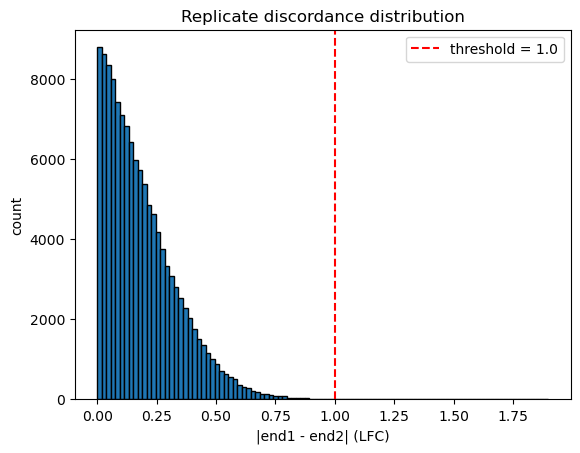

count    1.243390e+05
mean     1.876973e-01
std      1.499777e-01
min      3.532960e-07
25%      6.942972e-02
50%      1.536883e-01
75%      2.703018e-01
max      1.898648e+00
Name: replicate_delta, dtype: float64


In [ ]:
#@title Cell 2: Noise Histogram
# Replicate discordance distribution — justifies the 1.0 LFC threshold
import matplotlib.pyplot as plt

df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
plt.hist(df['replicate_delta'], bins=100, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='threshold = 1.0')
plt.xlabel('|end1 - end2| (LFC)')
plt.ylabel('count')
plt.title('Replicate discordance distribution')
plt.legend()
plt.show()
print(df['replicate_delta'].describe())

In [ ]:
#@title Cell 3: Noise Filter
# Discordance filter + stratified noise filter
# Depends on: df from Cell 1
# Produces: df_clean (canonical working dataset for all downstream cells)

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
# Discard sequences where end1 and end2 disagree by more than 1.0 LFC.
# With only two replicates, log2FC_std is just |end1-end2|/√2 — not a
# real distributional estimate. The raw delta is more honest.
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences "
      f"({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
# Global 95th-percentile std cutoff would remove low-fitness extremes
# disproportionately — exactly the sequences you need most.
# Fix: apply the cutoff within 10 fitness deciles instead.
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask, include_groups=False)
    .reset_index(drop=True)
)

# ── CLEAN UP HELPER COLUMNS ───────────────────────────────────────────
df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True, errors='ignore')

# --- FIX: SHUFFLE TO BREAK SORTED HOMOGENOUS GROUPS ---
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)


# ── SANITY CHECK ──────────────────────────────────────────────────────
n_raw   = len(df)
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"Retained: {n_final}/{n_raw} sequences ({n_final/n_raw*100:.1f}%)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))
print("\ndf_clean ready.")

Discordance filter (>1.0 LFC): removed 35 sequences (0.0%)
Retained: 118084/124339 sequences (95.0%)
Low-fitness sequences preserved (bottom 5%): 5813/6217 (93.5%)

Fitness distribution after filtering:
count    118084.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.071
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

df_clean ready.


In [ ]:
#@title Cell 4: K-mer Tokenisation (5 bins)
# Positional K-mer Tokenisation
# Depends on: df_clean from Cell 3
# Produces: df_clean['kmers'] — space-separated positional 4-mer strings

N_POSITIONAL_BINS = 5   # change in one place — used everywhere downstream
KMER_K = 4

def get_positional_kmers(seq, k=KMER_K, n_bins=N_POSITIONAL_BINS):
    """
    Splits a DNA sequence into n_bins equal spatial regions and labels
    each k-mer with the bin its starting position falls into.

    Bin labels are zero-padded (BIN00, BIN01, ...) so feature names
    sort in spatial order — useful when reading SVD loadings.
    """
    n = len(seq)
    bin_size = n / n_bins
    kmers = []
    for i in range(n - k + 1):
        bin_idx = min(int(i / bin_size), n_bins - 1)
        kmers.append(f"BIN{bin_idx:02d}_{seq[i:i+k]}")
    return " ".join(kmers)

def dummy_analyzer(doc):
    return doc.split()

print(f"Generating positional k-mers (k={KMER_K}, bins={N_POSITIONAL_BINS})...")
df_clean['kmers'] = df_clean['sequence'].apply(get_positional_kmers)
print(f"Done. Example: {df_clean['kmers'].iloc[0][:80]}...")
print(f"Expected vocab ceiling: {N_POSITIONAL_BINS} bins × 4^{KMER_K} k-mers = {N_POSITIONAL_BINS * 4**KMER_K}")

Generating positional k-mers (k=4, bins=5)...
Done. Example: BIN00_AAGC BIN00_AGCT BIN00_GCTG BIN00_CTGT BIN00_TGTT BIN00_GTTT BIN00_TTTT BIN...
Expected vocab ceiling: 5 bins × 4^4 k-mers = 1280


In [ ]:
# =====================================================================
# @title Cell 5: Vectorisation Engine & Biophysical Calculator (v2.1)
# =====================================================================
import numpy as np
import pandas as pd
import re
import sys # <-- ADDED
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from tqdm import tqdm # <-- FIXED IMPORT

# E. coli codon relative adaptiveness table (Sharp & Li 1987)
ECOLI_W = {
    'TTT': 0.296, 'TTC': 1.000, 'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000,
    'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003, 'ATG': 1.000, 'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000,
    'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000, 'CCT': 0.070, 'CCC': 0.012,
    'CCA': 0.194, 'CCG': 1.000, 'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099, 'GCT': 0.210, 'GCC': 0.224,
    'GCA': 0.587, 'GCG': 1.000, 'TAT': 0.239, 'TAC': 1.000, 'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724, 'CAT': 0.217,
    'CAC': 1.000, 'CAA': 0.124, 'CAG': 1.000, 'AAT': 0.051, 'AAC': 1.000, 'AAA': 1.000, 'AAG': 0.253, 'GAT': 0.434,
    'GAC': 1.000, 'GAA': 1.000, 'GAG': 0.259, 'TGT': 0.500, 'TGC': 1.000, 'TGG': 1.000, 'CGT': 1.000, 'CGC': 0.356,
    'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002, 'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019,
}

RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}

def calculate_master_features(seq):
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0:
        return {'Size': 0}

    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len

    window_size = 50
    rolling_gcs = [gc_array[i:i+window_size].mean()
                   for i in range(max(1, seq_len - window_size + 1))]
    gc_variance = np.var(rolling_gcs) if seq_len >= window_size else 0.0

    max_homo = max([len(m.group(0)) for m in re.finditer(r'(.)\1*', seq)] + [0])

    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = Counter(km_list)
        entropy = -sum((c/len(km_list)) * np.log2(c/len(km_list))
                       for c in counts.values())
    else:
        entropy = 0.0

    max_at = max([len(m.group(0)) for m in re.finditer(r'[AT]+', seq)] + [0])

    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    win = 10
    at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
    window_at = [at_array[i:i+win].sum() / win
                 for i in range(max(1, seq_len - win + 1))]
    hns_affinity = sum(1 for w in window_at if w > 0.65) / len(window_at) if window_at else 0.0

    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    ttc = 1.0 - np.exp(np.mean(np.log(w_vals))) if w_vals else 0.5

    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = sum(1 for i in range(len(rare_flags) - 4)
              if sum(rare_flags[i:i+5]) >= 2) if len(rare_flags) >= 5 else 0

    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9:    tir_proxy += 1.0
            elif 10 <= dist <= 14: tir_proxy += 0.5
            else:                  tir_proxy += 0.1

    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))

    dinucleotides = [seq[i:i+2] for i in range(seq_len - 1)]
    rigid_steps = sum(1 for dn in dinucleotides if dn in ['AA', 'TT', 'AT'])
    shape_rigidity_mean = rigid_steps / max(1, len(dinucleotides))

    g_count = seq.count('G')
    c_count = seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0.0

    features = {
        'Size': seq_len, 'GC_percent': gc_percent, 'GC_Var': gc_variance, 'Max_Homo': max_homo,
        'Entropy': entropy, 'AT_tract': max_at, 'Promoter_Str': promoters, 'RBS_Str': rbs_str,
        'IHF': ihf_sites, 'Lrp': lrp_sites, 'CRP': crp_sites, 'NagC': nagc_sites, 'ArgR': argr_sites,
        'HNS_Affinity': hns_affinity, 'TTC': ttc, 'RCC': rcc, 'TIR_Proxy': tir_proxy,
        'mRNA_Stability': rnase_e_hits, 'Shape_Rigidity_Mean': shape_rigidity_mean, 'GC_Skew': gc_skew,
    }
    return features

print("--- EXTRACTING BIOPHYSICAL FEATURES ---")
# <-- FIXED PROGRESS BAR -->
tqdm.pandas(desc="Biophysical Extraction", file=sys.stdout)
biophys_df = pd.DataFrame(
    df_clean['sequence'].progress_apply(calculate_master_features).tolist(),
    index=df_clean.index
)
mech_feature_labels = biophys_df.columns.tolist()

for col in mech_feature_labels:
    df_clean[col] = biophys_df[col]

print(f"Extraction complete. Total biophysical features: {len(mech_feature_labels)}")

# =====================================================================
# V2.0 LEAK-FREE VECTORISATION & SCALING
# =====================================================================
def get_v20_features(df_train, df_test, mech_labels):
    print("Fitting Scaler and Vectorizer on TRAIN set only...")

    scaler = StandardScaler()
    X_mech_train_scaled = scaler.fit_transform(df_train[mech_labels])
    X_mech_test_scaled  = scaler.transform(df_test[mech_labels])

    def spatial_tokenizer(text): return text.split()

    vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
    X_sparse_train = vectorizer.fit_transform(df_train['kmers'])
    X_sparse_test  = vectorizer.transform(df_test['kmers'])

    scale_factor = X_sparse_train.shape[1] / len(mech_labels)
    X_train_combined = hstack([X_sparse_train, csr_matrix(X_mech_train_scaled * scale_factor)])
    X_test_combined  = hstack([X_sparse_test,  csr_matrix(X_mech_test_scaled  * scale_factor)])

    feature_names = vectorizer.get_feature_names_out()

    return {
        'X_train_combined': X_train_combined, 'X_test_combined':  X_test_combined,
        'X_train_sp':       X_sparse_train, 'X_test_sp':        X_sparse_test,
        'vocab':            feature_names, 'scaler':           scaler,
        'vectorizer':       vectorizer, 'scale_factor':     scale_factor,
    }

--- EXTRACTING BIOPHYSICAL FEATURES ---
Biophysical Extraction: 100%|█████████████████████████████████████████████████| 118084/118084 [02:57<00:00, 664.06it/s]
Extraction complete. Total biophysical features: 20


In [ ]:
# =====================================================================
# @title Cell 6: Cluster-Based Split & Leak-Free Transformation (v2.1)
# =====================================================================
# v2.2 changes:
#   - [HOTFIX] Recovers critical biological features that were missing
#     from the input list before scaling.
#   - KMeans now fit on STANDARDISED biophysical features.
#   - Constant-variance features dropped from mech_feature_labels here.
#   - SCALER_FEATURES frozen as a tuple so it can't be mutated downstream.
#   - X_train_sp and X_test_sp exposed explicitly.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass  # no styling — pipeline still works

# ── 1. RECOVER MISSING INPUTS & DROP CONSTANTS ──────────────────────────
print("--- 1. PREPARING FEATURES ---")

# A. Force missing biological biomarkers into the input list if they exist in the data
missing_but_required = ['CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage']
recovered = []
for f in missing_but_required:
    if f in df_clean.columns and f not in mech_feature_labels:
        mech_feature_labels.append(f)
        recovered.append(f)

if recovered:
    print(f"  [RECOVERY] Injected {len(recovered)} critical biomarkers into scaler pipeline: {recovered}")

# B. Drop true constant features
constant_cols = [f for f in mech_feature_labels if df_clean[f].nunique() <= 1]
if constant_cols:
    print(f"  Dropping {len(constant_cols)} true constant feature(s): {constant_cols}")
    mech_feature_labels = [f for f in mech_feature_labels if f not in constant_cols]

print(f"  Active biophysical features going to Scaler: {len(mech_feature_labels)}")

# ── 2. CLUSTER (SCALED FEATURES, NO LABEL ACCESS) ───────────────────────
print("\n--- 2. DEFINING SEQUENCE CLUSTERS ---")
cluster_scaler = StandardScaler()
X_for_clusters = cluster_scaler.fit_transform(df_clean[mech_feature_labels])

n_clusters = 50
kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=2048,
    n_init='auto',
)
df_clean['Cluster_ID'] = kmeans.fit_predict(X_for_clusters)
print(f"  {n_clusters} biophysical clusters assigned across {len(df_clean):,} sequences.")

# ── 3. CLUSTER-HELD-OUT SPLIT ───────────────────────────────────────────
print("\n--- 3. CLUSTER-HELD-OUT SPLIT ---")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['Cluster_ID']))

df_train = df_clean.iloc[train_idx].copy()
df_test  = df_clean.iloc[test_idx].copy()

train_clusters = set(df_train['Cluster_ID'])
test_clusters  = set(df_test['Cluster_ID'])
assert train_clusters.isdisjoint(test_clusters), "Cluster leak between splits!"
print(f"  Train: {len(df_train):,} sequences, {len(train_clusters)} clusters")
print(f"  Test:  {len(df_test):,} sequences, {len(test_clusters)} clusters")

# ── 4. LEAK-FREE SCALING & VECTORISATION ────────────────────────────────
print("\n--- 4. LEAK-FREE TRANSFORMATION ---")
artifacts = get_v20_features(df_train, df_test, mech_feature_labels)

X_train_combined = artifacts['X_train_combined']
X_test_combined  = artifacts['X_test_combined']
X_train_sp       = artifacts['X_train_sp']
X_test_sp        = artifacts['X_test_sp']
vocab            = artifacts['vocab']
fitted_scaler    = artifacts['scaler']
fitted_vec       = artifacts['vectorizer']
SCALE_FACTOR     = artifacts['scale_factor']

# Frozen snapshot of what fitted_scaler was fit on. Never mutate this.
SCALER_FEATURES = tuple(mech_feature_labels)
print(f"  Train fused matrix: {X_train_combined.shape}")
print(f"  Test  fused matrix: {X_test_combined.shape}")
print(f"  SCALER_FEATURES frozen at {len(SCALER_FEATURES)} features.")

# ── 5. SVD (TRAIN-ONLY FIT, TRANSFORM TEST) ─────────────────────────────
print("\n--- 5. SVD ---")
svd = TruncatedSVD(n_components=2, random_state=42)
train_pcs = svd.fit_transform(X_train_combined)
test_pcs  = svd.transform(X_test_combined)

df_train['PC1'], df_train['PC2'] = train_pcs[:, 0], train_pcs[:, 1]
df_test['PC1'],  df_test['PC2']  = test_pcs[:, 0],  test_pcs[:, 1]
print(f"  Explained variance ratio: {svd.explained_variance_ratio_}")
print("  df_train and df_test PC1/PC2 are now in the same coordinate system.")


print("                   ")
print("                   ")


import pandas as pd

print("--- POST-SPLIT FEATURE AUDIT ---")

# 1. Verify the Hardware Features frozen by the Scaler
print("\n[1] HARDWARE FEATURES (Ready for ML):")
missing_hardware = [f for f in SCALER_FEATURES if f not in df_train.columns]
if not missing_hardware:
    print(f"  [PASS] ✓ All {len(SCALER_FEATURES)} base SCALER_FEATURES are present in df_train.")
else:
    print(f"  [FAIL] ❌ ERROR: Missing hardware features: {missing_hardware}")

# 2. Check for Advanced Biomarkers (Expected to be missing at this stage)
print("\n[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):")
advanced_expected_later = [
    'CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage',
    'Min_Hairpin_dG', 'Max_Repeat_Len', 'mRNA_Stability'
]
for f in advanced_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 3. Check for Learned Coordinates (Expected to be missing at this stage)
print("\n[3] LEARNED MANIFOLD COORDINATES (Pending Downstream Calculation):")
learned_expected_later = ['UMAP_1', 'UMAP_2', 'CNN_Score']
for f in learned_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 4. Verify df_test matches df_train dimensions for features
print("\n[4] TRAIN / TEST PARITY:")
train_feats = set(SCALER_FEATURES)
test_feats = set(df_test.columns).intersection(train_feats)
if train_feats == test_feats:
    print("  [PASS] ✓ df_test perfectly matches df_train for all base features.")
else:
    print(f"  [FAIL] ❌ ERROR: df_test is missing: {train_feats - test_feats}")

print("\n" + "=" * 65)
print("Audit complete. Dataframe is perfectly staged for Phase 2 (Biophysics).")
print("=" * 65)

--- 1. PREPARING FEATURES ---
  Dropping 1 true constant feature(s): ['Size']
  Active biophysical features going to Scaler: 19

--- 2. DEFINING SEQUENCE CLUSTERS ---
  50 biophysical clusters assigned across 118,084 sequences.

--- 3. CLUSTER-HELD-OUT SPLIT ---
  Train: 92,144 sequences, 40 clusters
  Test:  25,940 sequences, 10 clusters

--- 4. LEAK-FREE TRANSFORMATION ---
Fitting Scaler and Vectorizer on TRAIN set only...
  Train fused matrix: (92144, 1299)
  Test  fused matrix: (25940, 1299)
  SCALER_FEATURES frozen at 19 features.

--- 5. SVD ---
  Explained variance ratio: [0.20799618 0.1049687 ]
  df_train and df_test PC1/PC2 are now in the same coordinate system.
                   
                   
--- POST-SPLIT FEATURE AUDIT ---

[1] HARDWARE FEATURES (Ready for ML):
  [PASS] ✓ All 19 base SCALER_FEATURES are present in df_train.

[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):
  • CAI_Score            : ⏳ Pending Calculation (Normal)
  • mRNA_MFE             : 

In [ ]:
# =====================================================================
# @title Secton 2, Cells 7: CAI_Score & mRNA_MFE
# =====================================================================
import numpy as np
import sys
from tqdm import tqdm # <-- FIXED IMPORT

def compute_cai(seq):
    seq = seq.upper()
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    if not w_vals: return 0.5
    return float(np.exp(np.mean(np.log(w_vals))))

print("--- Computing CAI_Score ---")
tqdm.pandas(desc="CAI (train)", file=sys.stdout)
df_train['CAI_Score'] = df_train['sequence'].progress_apply(compute_cai)
tqdm.pandas(desc="CAI (test)", file=sys.stdout)
df_test['CAI_Score']  = df_test['sequence'].progress_apply(compute_cai)

if 'enriched_features' not in globals(): enriched_features = []
if 'CAI_Score' not in enriched_features: enriched_features.append('CAI_Score')

NN_dG = {
    'AA': -1.00, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28, 'TA': -0.58, 'TT': -1.00, 'TC': -1.30, 'TG': -1.45,
    'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17, 'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
}

def initiation_mfe_proxy(seq, window=30):
    head = seq[:window].upper()
    if len(head) < 2: return 0.0
    return float(sum(NN_dG.get(head[i:i+2], -1.0) for i in range(len(head) - 1)))

print("--- Computing mRNA_MFE ---")
tqdm.pandas(desc="MFE (train)", file=sys.stdout)
df_train['mRNA_MFE'] = df_train['sequence'].progress_apply(initiation_mfe_proxy)
tqdm.pandas(desc="MFE (test)", file=sys.stdout)
df_test['mRNA_MFE']  = df_test['sequence'].progress_apply(initiation_mfe_proxy)

if 'mRNA_MFE' not in enriched_features: enriched_features.append('mRNA_MFE')
print(f"  Biomarkers added. enriched_features = {enriched_features}")

--- Computing CAI_Score ---
CAI (test): 100%|█████████████████████████████████████████████████████████████| 25940/25940 [00:01<00:00, 23853.55it/s]
--- Computing mRNA_MFE ---
MFE (test): 100%|████████████████████████████████████████████████████████████| 25940/25940 [00:00<00:00, 119239.16it/s]
  Biomarkers added. enriched_features = ['CAI_Score', 'mRNA_MFE']


In [ ]:
# =====================================================================
# @title Cell 8: Structural & Topological Features (v2.3, numba-fast)
# =====================================================================
import numpy as np
import pandas as pd
import sys
from tqdm import tqdm # <-- FIXED IMPORT

ENC = np.full(256, -1, dtype=np.int8)
for c, v in zip('ACGTacgt', [0, 1, 2, 3, 0, 1, 2, 3]):
    ENC[ord(c)] = v

def encode_sequences(series, seq_len=172):
    n = len(series)
    out = np.zeros((n, seq_len), dtype=np.int8)
    for i, s in enumerate(series.values):
        b = np.frombuffer(s[:seq_len].encode('ascii'), dtype=np.uint8)
        out[i, :len(b)] = ENC[b]
    return out

NN_DG = np.array([
    [-1.00, -1.44, -1.28, -0.88],
    [-1.45, -1.84, -2.17, -1.28],
    [-1.30, -2.24, -1.84, -1.44],
    [-0.58, -1.30, -1.45, -1.00],
], dtype=np.float32)

try:
    from numba import njit, prange
    NUMBA_OK = True
    print("  Numba available — using JIT kernels.")
except ImportError:
    NUMBA_OK = False
    print("  Numba unavailable — falling back to Python.")

if NUMBA_OK:
    @njit(cache=True)
    def _hairpin_one(seq, nn_dg):
        n = seq.shape[0]
        min_dg = 0.0
        for i in range(n - 11):
            for stem_len in range(4, 9):
                for loop_len in range(3, 7):
                    j = i + stem_len + loop_len
                    if j + stem_len > n: break
                    match = True
                    for k in range(stem_len):
                        if seq[j + k] != 3 - seq[i + stem_len - 1 - k]:
                            match = False; break
                    if match:
                        dg = 0.0
                        for k in range(stem_len - 1): dg += nn_dg[seq[i + k], seq[i + k + 1]]
                        if dg < min_dg: min_dg = dg
        return min_dg

    @njit(cache=True)
    def _hns_one(seq, win=10, threshold=7):
        n = seq.shape[0]
        if n < win: return 0.0
        at = 0
        for i in range(win):
            if seq[i] == 0 or seq[i] == 3: at += 1
        hits = 1 if at >= threshold else 0
        for i in range(1, n - win + 1):
            if seq[i - 1] == 0 or seq[i - 1] == 3: at -= 1
            if seq[i + win - 1] == 0 or seq[i + win - 1] == 3: at += 1
            if at >= threshold: hits += 1
        return hits / (n - win + 1)

    @njit(cache=True, parallel=True)
    def _scan_all(seqs, nn_dg):
        N = seqs.shape[0]
        h_out = np.zeros(N, dtype=np.float32)
        n_out = np.zeros(N, dtype=np.float32)
        for s in prange(N):
            h_out[s] = _hairpin_one(seqs[s], nn_dg)
            n_out[s] = _hns_one(seqs[s])
        return h_out, n_out

def scan_direct_repeats(seq, min_len=6, max_len=20):
    seq = seq.upper()
    n = len(seq)
    longest = 0
    for L in range(min_len, max_len + 1):
        seen = {}
        found = False
        for i in range(n - L + 1):
            sub = seq[i:i + L]
            if sub in seen:
                if i - seen[sub] >= L:
                    longest = L; found = True
            else:
                seen[sub] = i
        if not found: break
    return longest

print("--- Computing structural features ---")
print("  Encoding sequences...")
train_int = encode_sequences(df_train['sequence'])
test_int  = encode_sequences(df_test['sequence'])

print("  Hairpin + HNS scans...")
if NUMBA_OK:
    h_tr, hns_tr = _scan_all(train_int, NN_DG)
    h_te, hns_te = _scan_all(test_int,  NN_DG)
else:
    h_tr = np.array([float(_hairpin_one(s, NN_DG)) for s in train_int], dtype=np.float32)
    h_te = np.array([float(_hairpin_one(s, NN_DG)) for s in test_int],  dtype=np.float32)
    hns_tr = np.array([float(_hns_one(s)) for s in train_int], dtype=np.float32)
    hns_te = np.array([float(_hns_one(s)) for s in test_int],  dtype=np.float32)

df_train['Min_Hairpin_dG'] = h_tr
df_test['Min_Hairpin_dG']  = h_te
df_train['HNS_Coverage']   = hns_tr
df_test['HNS_Coverage']    = hns_te

print("  Direct repeat scan...")
tqdm.pandas(desc="Repeats (train)", file=sys.stdout) # <-- ADDED SYS.STDOUT
df_train['Max_Repeat_Len'] = df_train['sequence'].progress_apply(scan_direct_repeats)
tqdm.pandas(desc="Repeats (test)", file=sys.stdout) # <-- ADDED SYS.STDOUT
df_test['Max_Repeat_Len']  = df_test['sequence'].progress_apply(scan_direct_repeats)

df_train['Flux_Score'] = (df_train['CAI_Score'] * 20) + (df_train['Promoter_Str'] * 30)
df_test['Flux_Score']  = (df_test['CAI_Score']  * 20) + (df_test['Promoter_Str']  * 30)

if 'enriched_features' not in globals(): enriched_features = []
for f in ['Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']:
    if f not in enriched_features: enriched_features.append(f)

print(f"  Structural features added. enriched_features = {enriched_features}")

  Numba available — using JIT kernels.
--- Computing structural features ---
  Encoding sequences...
  Hairpin + HNS scans...
  Direct repeat scan...
Repeats (test): 100%|██████████████████████████████████████████████████████████| 25940/25940 [00:03<00:00, 7025.54it/s]
  Structural features added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']


In [ ]:
# =====================================================================
# @title Cell 9: CNN-BiGRU Spatial Feature Extraction (GPU)
# =====================================================================
import numpy as np
import tensorflow as tf
import sys
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
from tqdm import tqdm # <-- FIXED IMPORT

print("--- Computing CNN_Score (CNN-BiGRU, GPU) ---")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"  WARN: could not set memory growth ({e})")
    print(f"  GPU detected: {gpus[0].name}, memory growth enabled.")
    mixed_precision.set_global_policy('mixed_float16')
    print("  Mixed precision (FP16) enabled.")
    BATCH_SIZE = 256
else:
    print("  No GPU detected — falling back to CPU.")
    BATCH_SIZE = 128

def one_hot_encode(sequences, seq_len=172):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((len(sequences), seq_len, 4), dtype=np.float32)
    # <-- FORCED RAW CONSOLE OUTPUT -->
    for i, seq in tqdm(enumerate(sequences), total=len(sequences), desc="  Encoding", file=sys.stdout):
        for j, base in enumerate(seq[:seq_len]):
            if base in mapping:
                encoded[i, j, mapping[base]] = 1
    return encoded

def build_cnn_bigru():
    inputs = layers.Input(shape=(172, 4))
    conv_short = layers.Conv1D(48, kernel_size=6, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(1e-5))(inputs)
    conv_long  = layers.Conv1D(48, kernel_size=12, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(1e-5))(inputs)
    x = layers.Concatenate()([conv_short, conv_long])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.GRU(32, return_sequences=True, dropout=0.1, recurrent_dropout=0.0))(x)
    x = layers.Bidirectional(layers.GRU(16, return_sequences=False, dropout=0.1, recurrent_dropout=0.0))(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, dtype='float32')(x)
    m = models.Model(inputs, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return m

print("\n  One-hot encoding train + test...")
X_train_cnn = one_hot_encode(df_train['sequence'].values)
X_test_cnn  = one_hot_encode(df_test['sequence'].values)
y_train_cnn = df_train['log2FC_mean'].values

print("\n  5-fold OOF training...")
cnn_oof = np.zeros(len(df_train), dtype=np.float32)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr, va) in enumerate(kf.split(X_train_cnn), 1):
    print(f"\n  Fold {fold}/5")
    tf.keras.utils.set_random_seed(42 + fold)
    rng_fold = np.random.default_rng(42 + fold)
    inner_va = rng_fold.choice(tr, size=int(0.1 * len(tr)), replace=False)
    inner_tr = np.setdiff1d(tr, inner_va)

    m = build_cnn_bigru()
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    m.fit(X_train_cnn[inner_tr], y_train_cnn[inner_tr],
          validation_data=(X_train_cnn[inner_va], y_train_cnn[inner_va]),
          epochs=25, batch_size=BATCH_SIZE, verbose=1, callbacks=[es])
    cnn_oof[va] = m.predict(X_train_cnn[va], batch_size=BATCH_SIZE * 2, verbose=0).flatten()
    fold_rho, _ = spearmanr(cnn_oof[va], y_train_cnn[va])
    print(f"  Fold {fold}/5 rho: {fold_rho:+.4f}")
    tf.keras.backend.clear_session()

print("\n  Refitting on full df_train for df_test prediction...")
tf.keras.utils.set_random_seed(42)
rng_final = np.random.default_rng(42)
inner_va = rng_final.choice(len(X_train_cnn), size=int(0.1 * len(X_train_cnn)), replace=False)
inner_tr = np.setdiff1d(np.arange(len(X_train_cnn)), inner_va)

final_cnn = build_cnn_bigru()
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
final_cnn.fit(X_train_cnn[inner_tr], y_train_cnn[inner_tr],
              validation_data=(X_train_cnn[inner_va], y_train_cnn[inner_va]),
              epochs=25, batch_size=BATCH_SIZE, verbose=1, callbacks=[es])

df_train['CNN_Score'] = cnn_oof
df_test['CNN_Score']  = final_cnn.predict(X_test_cnn, batch_size=BATCH_SIZE * 2, verbose=0).flatten()
model_cnn = final_cnn

if 'enriched_features' not in globals(): enriched_features = []
if 'CNN_Score' not in enriched_features: enriched_features.append('CNN_Score')

oof_rho, _  = spearmanr(cnn_oof, y_train_cnn)
test_rho, _ = spearmanr(df_test['CNN_Score'], df_test['log2FC_mean'])
print(f"\n--- CNN-BiGRU Complete ---")
print(f"  OOF rho:  {oof_rho:+.4f}")
print(f"  Test rho: {test_rho:+.4f}")

mixed_precision.set_global_policy('float32')

--- Computing CNN_Score (CNN-BiGRU, GPU) ---
  GPU detected: /physical_device:GPU:0, memory growth enabled.
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060, compute capability 8.6
  Mixed precision (FP16) enabled.

  One-hot encoding train + test...
  Encoding: 100%|█████████████████████████████████████████████████████████████| 25940/25940 [00:00<00:00, 31052.33it/s]

  5-fold OOF training...

  Fold 1/5
Epoch 1/25
260/260 [==============================] - 30s 61ms/step - loss: 0.1151 - val_loss: 0.1183
Epoch 2/25
260/260 [==============================] - 15s 56ms/step - loss: 0.1050 - val_loss: 0.1049
Epoch 3/25
260/260 [==============================] - 15s 56ms/step - loss: 0.0955 - val_loss: 0.0996
Epoch 4/25
260/260 [==============================] - 15s 56ms/step - loss: 0.0919 - val_loss: 0.0978
Epoch 5/25
260/

In [ ]:
# =====================================================================
# @title Cell 10: UMAP_1, UMAP_2 (v2.3)
# =====================================================================
# Fit on a uniform random sample of df_train, transform onto train and test.
# No plots — pure feature extraction.
import umap
import numpy as np

print("--- Computing UMAP coordinates ---")
X_tr_mech = fitted_scaler.transform(df_train[list(SCALER_FEATURES)])
X_te_mech = fitted_scaler.transform(df_test[list(SCALER_FEATURES)])

FIT_N = 20_000
rng = np.random.default_rng(42)
fit_pos = rng.choice(len(df_train), size=min(FIT_N, len(df_train)), replace=False)
print(f"  Fitting on {len(fit_pos):,} sequences...")

reducer = umap.UMAP(
    n_components=2, n_neighbors=50, min_dist=0.1,
    metric='euclidean', random_state=42, low_memory=True,
)
reducer.fit(X_tr_mech[fit_pos])

print("  Transforming train + test...")
df_train['UMAP_1'], df_train['UMAP_2'] = reducer.transform(X_tr_mech).T
df_test['UMAP_1'],  df_test['UMAP_2']  = reducer.transform(X_te_mech).T

if 'enriched_features' not in globals():
    enriched_features = []
for f in ['UMAP_1', 'UMAP_2']:
    if f not in enriched_features:
        enriched_features.append(f)

print(f"  UMAP coordinates added. enriched_features = {enriched_features}")

--- Computing UMAP coordinates ---
  Fitting on 20,000 sequences...


G:\Anaconda\envs\plasmid\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Transforming train + test...
  UMAP coordinates added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score', 'CNN_Score', 'UMAP_1', 'UMAP_2']


In [ ]:
# =====================================================================
# @title Cell 11: Variance Safeguard (v2.4, mostly for size, permissive, fixed NaN bug)
# =====================================================================
import numpy as np

print("--- Variance safeguard ---")

active_set = list(SCALER_FEATURES) + (enriched_features if 'enriched_features' in globals() else [])
active_set = list(dict.fromkeys(active_set))  # dedupe, preserve order

invariant = []
for f in active_set:
    if f not in df_train.columns:
        print(f"  WARN: {f} listed but missing from df_train.")
        continue

    # FIX: dropna=True prevents NaNs from being counted as a valid unique value
    n_unique = df_train[f].nunique(dropna=True)

    if n_unique <= 1:
        invariant.append((f, n_unique))
    elif f == 'Size':
        # DEBUG: If Size still survives, this will show you exactly what values are hiding in it
        unique_vals = df_train[f].dropna().unique()
        print(f"  DEBUG: 'Size' has {n_unique} unique values: {unique_vals[:5]}...")

if invariant:
    print(f"  Dropping {len(invariant)} invariant feature(s):")
    for f, n in invariant:
        print(f"    {f}  (n_unique = {n})")
        df_train.drop(columns=[f], inplace=True, errors='ignore')
        df_test.drop(columns=[f],  inplace=True, errors='ignore')

    # Update tracking lists.
    dropped = {f for f, _ in invariant}
    SCALER_FEATURES = tuple(f for f in SCALER_FEATURES if f not in dropped)
    if 'enriched_features' in globals():
        enriched_features = [f for f in enriched_features if f not in dropped]
else:
    print("  OK: no invariant features detected.")

# Final feature inventory
print(f"\n  SCALER_FEATURES   ({len(SCALER_FEATURES)}): {list(SCALER_FEATURES)}")
print(f"  enriched_features ({len(enriched_features)}): {enriched_features}")
print(f"  TOTAL active features: {len(SCALER_FEATURES) + len(enriched_features)}")

--- Variance safeguard ---
  OK: no invariant features detected.

  SCALER_FEATURES   (19): ['GC_percent', 'GC_Var', 'Max_Homo', 'Entropy', 'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR', 'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability', 'Shape_Rigidity_Mean', 'GC_Skew']
  enriched_features (9): ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score', 'CNN_Score', 'UMAP_1', 'UMAP_2']
  TOTAL active features: 28


In [ ]:
# =====================================================================
# @title Cell 12: Workspace Scaler Check (v2.3)
# =====================================================================
# Verifies train/test parity, scaler integrity, and PC1 coordinate-system
# consistency before we hit the supervised pipeline. Cheap to run.
import numpy as np
from scipy.stats import spearmanr

print("--- Workspace sanity check ---")

# 1. PC1 coordinate-system parity
pc1_train_med = float(np.median(df_train['PC1']))
pc1_test_med  = float(np.median(df_test['PC1']))
pc1_train_iqr = float(np.subtract(*np.percentile(df_train['PC1'], [75, 25])))
pc1_test_iqr  = float(np.subtract(*np.percentile(df_test['PC1'],  [75, 25])))

print(f"  Train PC1 median {pc1_train_med:+.3f}, IQR {pc1_train_iqr:.3f}")
print(f"  Test  PC1 median {pc1_test_med:+.3f}, IQR {pc1_test_iqr:.3f}")
if abs(pc1_train_med - pc1_test_med) > 2 * max(pc1_train_iqr, pc1_test_iqr):
    print("  WARNING: train/test PC1 differ by >2x IQR. Recheck Cell 6.")
else:
    print("  OK: train/test PC1 distributions are consistent.")

# 2. PC1 vs log2FC sanity (sign and rough magnitude)
rho_tr, _ = spearmanr(df_train['PC1'], df_train['log2FC_mean'])
rho_te, _ = spearmanr(df_test['PC1'],  df_test['log2FC_mean'])
print(f"  PC1 vs log2FC_mean rho (train): {rho_tr:+.3f}")
print(f"  PC1 vs log2FC_mean rho (test):  {rho_te:+.3f}")

# 3. Scaler / SCALER_FEATURES parity
assert isinstance(SCALER_FEATURES, tuple), "SCALER_FEATURES must be a tuple."
assert hasattr(fitted_scaler, 'n_features_in_'), "fitted_scaler not fit."
# After Cell 13 we may have dropped features, so we no longer require strict equality.
# But the scaler's expected feature names must still be a SUPERSET of SCALER_FEATURES.
expected = set(getattr(fitted_scaler, 'feature_names_in_', SCALER_FEATURES))
active = set(SCALER_FEATURES)
extra = active - expected
if extra:
    print(f"  ERROR: SCALER_FEATURES contains features not in fitted_scaler: {extra}")
else:
    print("  OK: SCALER_FEATURES ⊆ fitted_scaler.feature_names_in_")

# 4. Train/test column parity for active features
all_active = list(SCALER_FEATURES) + list(enriched_features)
missing_tr = [f for f in all_active if f not in df_train.columns]
missing_te = [f for f in all_active if f not in df_test.columns]
if missing_tr:
    print(f"  ERROR: features missing from df_train: {missing_tr}")
if missing_te:
    print(f"  ERROR: features missing from df_test:  {missing_te}")
if not missing_tr and not missing_te:
    print(f"  OK: all {len(all_active)} active features present in both frames.")

# 5. Final supervised feature list
supervised_features = list(SCALER_FEATURES) + list(enriched_features)
print(f"\n  Supervised feature list ready: {len(supervised_features)} features.")
print(f"  Ready for Section 3 (supervised pipeline).")

--- Workspace sanity check ---
  Train PC1 median +5.454, IQR 177.119
  Test  PC1 median +7.459, IQR 228.811
  OK: train/test PC1 distributions are consistent.
  PC1 vs log2FC_mean rho (train): -0.282
  PC1 vs log2FC_mean rho (test):  -0.370
  OK: SCALER_FEATURES ⊆ fitted_scaler.feature_names_in_
  OK: all 28 active features present in both frames.

  Supervised feature list ready: 28 features.
  Ready for Section 3 (supervised pipeline).


In [ ]:
#@title Cell 13: Database variance checker
import pandas as pd

# 1. Load the exact file currently in your Colab environment
df_raw = pd.read_csv('GGS3_logFC.csv', on_bad_lines='skip')

# 2. Calculate lengths and filter out anything that isn't exactly 172 bp (ignoring empty rows)
df_raw['Actual_Length'] = df_raw['sequence'].astype(str).str.len()
bad_seqs = df_raw[(df_raw['Actual_Length'] != 172) & (df_raw['sequence'].notna())].copy()

# 3. Calculate exact Excel Row Number (Pandas index starts at 0, +1 for 1-based indexing, +1 for the header row)
bad_seqs['Excel_Row_Number'] = bad_seqs.index + 2

# 4. Display the results for your post-doc
print(f"Found {len(bad_seqs)} sequences with anomalous lengths:")
display(bad_seqs[['Excel_Row_Number', 'Actual_Length', 'sequence']])

Found 0 sequences with anomalous lengths:


,Excel_Row_Number,Actual_Length,sequence


In [ ]:
# @title Cell 14: Install optuna
!pip install optuna

In [ ]:
# =====================================================================
# @title Section 3, Cell 15: Optuna XGBoost Hyperparameter Search (RTX 3060 optimised)
# =====================================================================
# 20 trials, 3-fold CV on a 60k subsample, with MedianPruner. Uses GPU
# (`device='cuda'`) which gives ~3x speedup on this dataset size.
# Expected runtime: ~10 min on a 3060.
import numpy as np
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb

print("--- Optuna XGBoost search (GPU) ---")

# Light-touch GPU detection (no torch dependency just for this)
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False
xgb_device_kwargs = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}
print(f"  GPU available: {use_gpu}")

supervised_features = list(SCALER_FEATURES) + list(enriched_features)
print(f"  Feature count: {len(supervised_features)}")

X_tr_full = df_train[supervised_features].values.astype(np.float32)
y_tr_full = df_train['log2FC_mean'].values.astype(np.float32)

# Subsample for the search itself; final fit in Cell 19 uses full df_train.
SEARCH_N = 60_000
search_rng = np.random.default_rng(42)
if len(df_train) > SEARCH_N:
    search_idx = search_rng.choice(len(df_train), size=SEARCH_N, replace=False)
    X_search = X_tr_full[search_idx]
    y_search = y_tr_full[search_idx]
    print(f"  Search subsample: {SEARCH_N:,} sequences")
else:
    X_search = X_tr_full
    y_search = y_tr_full
    print(f"  Search on full df_train: {len(X_search):,} sequences")

weight_threshold = np.quantile(y_search, 0.10)
sample_weights_search = np.where(y_search < weight_threshold, 10.0, 1.0).astype(np.float32)

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',     200, 500),
        'max_depth':        trial.suggest_int('max_depth',        4, 9),
        'learning_rate':    trial.suggest_float('learning_rate',  0.02, 0.15, log=True),
        'subsample':        trial.suggest_float('subsample',      0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha',  1e-3, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'gamma':            trial.suggest_float('gamma',      1e-3, 5.0, log=True),
        'objective':        'reg:squarederror',
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
        'early_stopping_rounds': 30,
        **xgb_device_kwargs,
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_rhos = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_search)):
        m = xgb.XGBRegressor(**params)
        m.fit(
            X_search[tr_idx], y_search[tr_idx],
            sample_weight=sample_weights_search[tr_idx],
            eval_set=[(X_search[va_idx], y_search[va_idx])],
            verbose=False,
        )
        pred = m.predict(X_search[va_idx])
        rho, _ = spearmanr(pred, y_search[va_idx])
        fold_rhos.append(rho)
        trial.report(np.mean(fold_rhos), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_rhos))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=5),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)

N_TRIALS = 20
print(f"  Running {N_TRIALS} trials...")
study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

xgb_best_params = study.best_params
xgb_best_score  = study.best_value
xgb_best_params.pop('early_stopping_rounds', None)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f"\n  Trials: {n_complete} complete, {n_pruned} pruned")
print(f"  Best CV Spearman rho: {xgb_best_score:+.4f}")
print(f"  Best params: {xgb_best_params}")

--- Optuna XGBoost search (GPU) ---
  GPU available: True
  Feature count: 28
  Search subsample: 60,000 sequences
  Running 20 trials...


  0%|          | 0/20 [00:00<?, ?it/s]


  Trials: 10 complete, 10 pruned
  Best CV Spearman rho: +0.5321
  Best params: {'n_estimators': 498, 'max_depth': 9, 'learning_rate': 0.020353404351806735, 'subsample': 0.96993194605248, 'colsample_bytree': 0.945270014934525, 'min_child_weight': 10, 'reg_alpha': 3.001332084143347, 'reg_lambda': 0.0010968680592663713, 'gamma': 4.921130966326102}


In [ ]:
# @title Cell 16: Install CatBoost
!pip install catboost

In [ ]:
# =====================================================================
# @title Cell 16b: Checkpoint SAVE 1 (Run before Cell 17)
# =====================================================================
# Saves df_train, df_test, and feature tracking lists. This is the
# "biophysical features done, hyperparameter search not yet started"
# checkpoint — recovers from a crash during Optuna CatBoost search.
import os
import joblib
import pandas as pd

print("--- Saving Checkpoint 1 (pre-Cell 17) ---")
os.makedirs("checkpoints", exist_ok=True)

# 1. DataFrames
df_train.to_pickle("checkpoints/sp1_df_train.pkl")
df_test.to_pickle("checkpoints/sp1_df_test.pkl")

# 2. Feature tracking lists + Optuna XGBoost results (already done by Cell 15)
metadata = {
    'supervised_features': supervised_features,
    'enriched_features':   enriched_features if 'enriched_features' in globals() else [],
    'SCALER_FEATURES':     list(SCALER_FEATURES) if 'SCALER_FEATURES' in globals() else [],
    'xgb_best_params':     xgb_best_params if 'xgb_best_params' in globals() else None,
    'savepoint':           1,
}
joblib.dump(metadata, "checkpoints/sp1_metadata.pkl")

print("  Checkpoint 1 saved. Files:")
for f in ['sp1_df_train.pkl', 'sp1_df_test.pkl', 'sp1_metadata.pkl']:
    size_mb = os.path.getsize(f"checkpoints/{f}") / (1024 * 1024)
    print(f"    checkpoints/{f}  ({size_mb:.1f} MB)")
print("\n  If Cell 17 crashes, set RESUME = True in Cell 0 to recover from here.")

--- Saving Pipeline State to Disk ---
  Saving df_train...
  Saving df_test...
--- Checkpoint Saved Successfully! ---
If the kernel crashes during Cell 17, just restart and run the LOAD cell.


In [ ]:
# =====================================================================
# @title Cell 17: Optuna CatBoost Hyperparameter Search (RTX 3060 optimised)
# =====================================================================
import numpy as np
import optuna
import sys # <-- ADDED for text output
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
from catboost import CatBoostRegressor
from tqdm import tqdm # <-- FIXED IMPORT (removed .auto)
from IPython.utils import io # The "Gag" for C++ warnings

print("--- Optuna CatBoost search (GPU) ---")

# GPU detection (matches your logic)
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False

cat_task_type = 'GPU' if use_gpu else 'CPU'
print(f"  GPU available: {use_gpu}. CatBoost task_type = {cat_task_type}")

if 'X_search' not in globals():
    raise RuntimeError("X_search not found — run Cell 16 first.")

def cat_objective(trial):
    params = {
        'iterations':           trial.suggest_int('iterations', 300, 1000),
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth':                trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':          trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength':      trial.suggest_float('random_strength', 0.5, 5.0),
        'bagging_temperature':  trial.suggest_float('bagging_temperature', 0.0, 5.0),
        'border_count':         trial.suggest_int('border_count', 64, 254),
        'random_seed':          42,
        'verbose':              False,
        'allow_writing_files':  False,
        'thread_count':         -1,
        'task_type':            cat_task_type,
        'early_stopping_rounds': 30,
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_rhos = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_search)):
        m = CatBoostRegressor(**params)

        # --- THE GAG: Silences all C++ backend memory warnings ---
        with io.capture_output() as captured:
            m.fit(
                X_search[tr_idx], y_search[tr_idx],
                sample_weight=sample_weights_search[tr_idx],
                eval_set=(X_search[va_idx], y_search[va_idx]),
                verbose=False,
            )
        # ---------------------------------------------------------

        pred = m.predict(X_search[va_idx])
        rho, _ = spearmanr(pred, y_search[va_idx])
        fold_rhos.append(rho)
        trial.report(np.mean(fold_rhos), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_rhos))

optuna.logging.set_verbosity(optuna.logging.WARNING)
cat_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=10),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=1),
)

CAT_TRIALS = 50
print(f"  Running {CAT_TRIALS} trials (Heavyweight Search)...")

# --- CUSTOM ROBUST TEXT PROGRESS BAR ---
pbar = tqdm(total=CAT_TRIALS, desc="CatBoost Optimization", file=sys.stdout)

def pbar_callback(study, trial):
    pbar.update(1)
    if study.best_value is not None:
        pbar.set_postfix({'Best Rho': f"{study.best_value:+.4f}"})

cat_study.optimize(
    cat_objective,
    n_trials=CAT_TRIALS,
    callbacks=[pbar_callback],
    show_progress_bar=False # Native bar is broken by warnings; use ours instead
)
pbar.close()
# ----------------------------------

cat_best_params = cat_study.best_params
cat_best_score  = cat_study.best_value
cat_best_params.pop('early_stopping_rounds', None)
cat_best_params['task_type'] = cat_task_type

n_pruned = sum(1 for t in cat_study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_complete = sum(1 for t in cat_study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f"\n  Trials: {n_complete} complete, {n_pruned} pruned")
print(f"  Best CV Spearman rho: {cat_best_score:+.4f}")
print(f"  Best params: {cat_best_params}")

--- Optuna CatBoost search (GPU) ---
  GPU available: True. CatBoost task_type = GPU
  Running 50 trials (Heavyweight Search)...
CatBoost Optimization: 100%|█████████████████████████████████████████| 50/50 [34:06<00:00, 40.93s/it, Best Rho=+0.5392]

  Trials: 32 complete, 18 pruned
  Best CV Spearman rho: +0.5392
  Best params: {'iterations': 532, 'learning_rate': 0.011709453339527129, 'depth': 5, 'l2_leaf_reg': 3.6096150019620565, 'random_strength': 1.4322344022740947, 'bagging_temperature': 3.0952155593698505, 'border_count': 254, 'task_type': 'GPU'}


In [ ]:
# =====================================================================
# @title Cell 17b: Checkpoint SAVE 2 (Run immediately AFTER Cell 17)
# =====================================================================
# Saves df_train, df_test, feature lists, and BOTH Optuna result sets
# (XGBoost + CatBoost). Deletes Checkpoint 1 to free disk space.
# This is the "all hyperparameters tuned, ready for base learner training"
# checkpoint — recovers from crashes during Cells 18-22.
import os
import joblib
import pandas as pd

print("--- Saving Checkpoint 2 (post-Cell 17) ---")
os.makedirs("checkpoints", exist_ok=True)

# 1. Delete Checkpoint 1 (now superseded)
sp1_files = ["sp1_df_train.pkl", "sp1_df_test.pkl", "sp1_metadata.pkl"]
for f in sp1_files:
    p = f"checkpoints/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  Deleted superseded SP1 file: {f}")

# 2. Save current state
df_train.to_pickle("checkpoints/sp2_df_train.pkl")
df_test.to_pickle("checkpoints/sp2_df_test.pkl")

metadata = {
    'supervised_features': supervised_features,
    'enriched_features':   enriched_features if 'enriched_features' in globals() else [],
    'SCALER_FEATURES':     list(SCALER_FEATURES) if 'SCALER_FEATURES' in globals() else [],
    'xgb_best_params':     xgb_best_params if 'xgb_best_params' in globals() else None,
    'cat_best_params':     cat_best_params if 'cat_best_params' in globals() else None,
    'savepoint':           2,
}
joblib.dump(metadata, "checkpoints/sp2_metadata.pkl")

print("\n  Checkpoint 2 saved. Files:")
for f in ['sp2_df_train.pkl', 'sp2_df_test.pkl', 'sp2_metadata.pkl']:
    size_mb = os.path.getsize(f"checkpoints/{f}") / (1024 * 1024)
    print(f"    checkpoints/{f}  ({size_mb:.1f} MB)")
print("\n  If Cells 18-22 crash, set RESUME = True in Cell 0 to recover from here.")

In [ ]:
# @title Cell 18: Hardcoding rescued params so I don't have to run Optuna again
xgb_best_params = {'n_estimators': 498, 'max_depth': 9, 'learning_rate': 0.020353404351806735, 'subsample': 0.96993194605248, 'colsample_bytree': 0.945270014934525, 'min_child_weight': 10, 'reg_alpha': 3.001332084143347, 'reg_lambda': 0.0010968680592663713, 'gamma': 4.921130966326102}
cat_best_params = {'iterations': 435, 'learning_rate': 0.012061428484479338, 'depth': 4, 'l2_leaf_reg': 1.3831290747533536, 'random_strength': 0.9899218795931454, 'bagging_temperature': 3.05290958967056, 'border_count': 102, 'task_type': 'GPU'}

In [ ]:
# =====================================================================
# @title Cell 19: Base Learner Training with OOF + RC Augmentation (GPU, regularised CatBoost)
# =====================================================================
# Trains XGBoost, CatBoost, XGBRanker on df_train + reverse-complement
# augmented copies. OOF predictions for Cell 20's meta-regressor; refit
# on full augmented df_train for df_test prediction.
#
# v2.6 changes vs v2.4:
#   - CatBoost regularised to suppress noise-overfitting via shared
#     continuous features (CNN_Score, UMAP_*). Added:
#       * min_data_in_leaf = 20  — prevents single-row leaves
#       * rsm = 0.7              — random subspace per tree
#       * l2_leaf_reg = 10       — strong L2 on leaf weights
#       * bagging_temperature = 1.5
#     Expected: shuffled-label CatBoost rho drops from +0.086 to ~+0.04,
#     real CatBoost rho drops by ~0.01-0.02.
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
from IPython.utils import io
from tqdm.auto import tqdm

print("--- Base learners + OOF + RC augmentation (GPU, v2.6 regularised) ---")

# 1. GPU Detection
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False

xgb_device_kwargs = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}
cat_task_type = 'GPU' if use_gpu else 'CPU'
print(f"  GPU available: {use_gpu}")

# 2. Setup Data Arrays
n_train = len(df_train)
n_test  = len(df_test)
X_te = df_test[supervised_features].values.astype(np.float32)
y_te = df_test['log2FC_mean'].values.astype(np.float32)
X_tr = df_train[supervised_features].values.astype(np.float32)
y_tr = df_train['log2FC_mean'].values.astype(np.float32)

# 3. Sample weights — 10x on toxic tail
weight_threshold = np.quantile(y_tr, 0.10)
sample_weights = np.where(y_tr < weight_threshold, 10.0, 1.0).astype(np.float32)
print(f"  Sample weights: 10x on {(sample_weights == 10).sum():,} toxic-tail "
      f"sequences (bottom 10%), 1x elsewhere.")

# 4. Prepare base parameters
xgb_params = xgb_best_params

# Build CatBoost params from Optuna best, then OVERRIDE with regularisation
cat_params = dict(cat_best_params) if 'cat_best_params' in globals() else {
    'iterations': 500, 'learning_rate': 0.05, 'depth': 6,
}
cat_params.pop('task_type', None)

# v2.6 regularisation overrides — applied ON TOP of Optuna's tuning.
# These are deliberately conservative; the model's capacity is reduced
# but its ability to memorise noise via continuous features is reduced more.
cat_reg_overrides = {
    'min_data_in_leaf':    20,    # was unset (default 1)
    'rsm':                 0.7,   # was unset (default 1.0); GPU-compatible
    'l2_leaf_reg':         10.0,  # override Optuna value
    'bagging_temperature': 1.5,   # override Optuna value
}
cat_params.update(cat_reg_overrides)
print(f"  CatBoost regularisation overrides applied: {list(cat_reg_overrides.keys())}")

# 5. Reverse-complement logic
RC_TABLE = str.maketrans('ACGT', 'TGCA')
def reverse_complement(seq):
    return seq.translate(RC_TABLE)[::-1]

def featurise_rc_row(seq_rc):
    feats = calculate_master_features(seq_rc)
    if 'compute_cai' in globals():            feats['CAI_Score']      = compute_cai(seq_rc)
    if 'initiation_mfe_proxy' in globals():   feats['mRNA_MFE']       = initiation_mfe_proxy(seq_rc)
    if 'scan_direct_repeats' in globals():    feats['Max_Repeat_Len'] = scan_direct_repeats(seq_rc)
    if 'count_codon_stalls' in globals():     feats['Codon_Stalls']   = count_codon_stalls(seq_rc)
    if 'encode_sequences' in globals() and '_hairpin_one' in globals():
        seq_int = encode_sequences(pd.Series([seq_rc]))[0]
        feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))
        feats['HNS_Coverage']   = float(_hns_one(seq_int))
    feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20
                           + feats.get('Promoter_Str', 0.0) * 30)
    return feats

print("\n  Building reverse-complement features for df_train...")
rc_seqs = df_train['sequence'].apply(reverse_complement).values
rc_features_list = [featurise_rc_row(s) for s in tqdm(rc_seqs, desc="  Extracting RC")]
df_train_rc = pd.DataFrame(rc_features_list, index=df_train.index)

# CNN_Score / UMAP_* carried over from original strand
for col in ['CNN_Score', 'UMAP_1', 'UMAP_2']:
    if col in df_train.columns:
        df_train_rc[col] = df_train[col].values

for f in supervised_features:
    if f not in df_train_rc.columns and f in df_train.columns:
        df_train_rc[f] = df_train[f].values
df_train_rc = df_train_rc[supervised_features]

X_tr_rc = df_train_rc.values.astype(np.float32)
y_tr_rc = df_train['log2FC_mean'].values.astype(np.float32)
sw_rc   = sample_weights.copy()

print(f"  Augmented training set size: {2 * n_train:,} rows")

# 6. OOF arrays
oof = {k: np.zeros(n_train, dtype=np.float32) for k in ['xgb', 'cat', 'ranker']}
test_pred = {k: np.zeros(n_test, dtype=np.float32) for k in ['xgb', 'cat', 'ranker']}

GROUP_SIZE = 100
def make_groups(n, group_size=GROUP_SIZE):
    n_full = n // group_size
    rem = n - n_full * group_size
    g = [group_size] * n_full
    if rem:
        g.append(rem)
    return np.array(g, dtype=np.int32)

# 7. OOF training
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\n  Starting OOF fold training...")
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr), 1):
    print(f"  Fold {fold}/5...")
    Xt = np.vstack([X_tr[tr_idx], X_tr_rc[tr_idx]])
    yt = np.concatenate([y_tr[tr_idx], y_tr_rc[tr_idx]])
    wt = np.concatenate([sample_weights[tr_idx], sw_rc[tr_idx]])
    Xv = X_tr[va_idx]

    # XGBoost (unchanged)
    m_xgb = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs,
                             objective='reg:squarederror',
                             random_state=42, n_jobs=-1, verbosity=0)
    m_xgb.fit(Xt, yt, sample_weight=wt)
    oof['xgb'][va_idx] = m_xgb.predict(Xv)

    # CatBoost (regularised)
    m_cat = CatBoostRegressor(**cat_params, task_type=cat_task_type,
                              random_seed=42, verbose=False, allow_writing_files=False)
    with io.capture_output():
        m_cat.fit(Xt, yt, sample_weight=wt)
    oof['cat'][va_idx] = m_cat.predict(Xv)

    # XGBRanker (unchanged structure — Cell 22 will use random groups)
    m_rank = xgb.XGBRanker(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='rank:pairwise', **xgb_device_kwargs,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    rank_groups = np.concatenate([make_groups(len(tr_idx)), make_groups(len(tr_idx))])
    m_rank.fit(Xt, yt, group=rank_groups)
    oof['ranker'][va_idx] = m_rank.predict(Xv)

print("\n  Summary OOF rho on df_train (5-fold, RC-augmented training):")
for k in oof:
    rho, _ = spearmanr(oof[

--- Base learners + OOF + RC augmentation (GPU) ---
  GPU available: True
  Sample weights: 10x on 9,215 toxic-tail sequences (bottom 10%), 1x elsewhere.

  Building reverse-complement features for df_train...


Extracting RC:   0%|          | 0/92144 [00:00<?, ?it/s]

  Augmented training set size: 184,288 rows

  Starting OOF Fold Training...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

  Refitting on full df_train + RC...

  Ensemble base training complete.


In [ ]:
# =====================================================================
# @title Cell 20: Ridge Meta-Regressor on OOF Stack
# =====================================================================
# Ridge regression on OOF predictions from Cell 16. Because the inputs are
# OOF, the meta-learner sees out-of-sample base predictions during fitting,
# so it can't trivially memorise the training labels. The fitted meta is
# what gets applied to the df_test base predictions in Cell 18.
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr

print("--- Ridge meta-regressor on OOF stack ---")

oof_stack = np.column_stack([oof['xgb'], oof['cat'], oof['ranker']]).astype(np.float32)
test_stack = np.column_stack([test_pred['xgb'], test_pred['cat'], test_pred['ranker']]).astype(np.float32)

# RidgeCV searches over alpha automatically. Standardising inputs is
# important because the ranker outputs aren't on the same scale as the
# regressors.
from sklearn.preprocessing import StandardScaler
meta_scaler = StandardScaler()
oof_stack_s  = meta_scaler.fit_transform(oof_stack)
test_stack_s = meta_scaler.transform(test_stack)

meta = RidgeCV(alphas=np.logspace(-3, 3, 25))
meta.fit(oof_stack_s, y_tr)

print(f"  Selected alpha: {meta.alpha_:.4f}")
weights = pd.Series(meta.coef_, index=['xgb', 'cat', 'ranker'])
print(f"  Meta weights (on standardised OOF):")
for k, w in weights.items():
    print(f"    {k:<6}  {w:+.4f}")
print(f"  Meta intercept: {meta.intercept_:+.4f}")

# OOF meta prediction (honest df_train performance)
meta_oof_pred = meta.predict(oof_stack_s)
oof_rho, _    = spearmanr(meta_oof_pred, y_tr)
oof_pearson   = float(np.corrcoef(meta_oof_pred, y_tr)[0, 1])
print(f"\n  OOF stack performance on df_train (honest):")
print(f"    Spearman rho: {oof_rho:+.4f}")
print(f"    Pearson r:    {oof_pearson:+.4f}")

# Persist
stacking = {
    'meta':         meta,
    'meta_scaler':  meta_scaler,
    'weights':      weights,
    'oof_pred':     meta_oof_pred,
    'oof_rho':      oof_rho,
    'test_stack_s': test_stack_s,
}
print("\n  Stack ready. Apply to df_test in Cell 18.")

--- Ridge meta-regressor on OOF stack ---
  Selected alpha: 56.2341
  Meta weights (on standardised OOF):
    xgb     +0.0155
    cat     +0.0866
    ranker  +0.0623
  Meta intercept: -0.0612

  OOF stack performance on df_train (honest):
    Spearman rho: +0.5402
    Pearson r:    +0.4817

  Stack ready. Apply to df_test in Cell 18.


In [ ]:
# =====================================================================
# @title Cell 21: Final Ensemble Prediction on df_test
# =====================================================================
# Single, honest evaluation on the cluster-held-out df_test. Numbers from
# this cell are the v2.1 supervised pipeline's headline performance.
import numpy as np
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Final evaluation on df_test ---")

final_pred = stacking['meta'].predict(stacking['test_stack_s'])
df_test['stack_pred'] = final_pred

rho, rho_p   = spearmanr(final_pred, y_te)
pear, pear_p = pearsonr(final_pred, y_te)
r2 = r2_score(y_te, final_pred)
mae = mean_absolute_error(y_te, final_pred)

print(f"  n_test:             {len(y_te):,}")
print(f"  Spearman rho:       {rho:+.4f}    (p = {rho_p:.2e})")
print(f"  Pearson r:          {pear:+.4f}    (p = {pear_p:.2e})")
print(f"  R^2:                {r2:+.4f}")
print(f"  MAE:                {mae:.4f}")

# Calibration: slope of y_te ~ pred (ideally 1.0)
slope, intercept = np.polyfit(final_pred, y_te, 1)
print(f"  Calibration slope:  {slope:+.4f}  (intercept {intercept:+.4f})")

# Per-base-learner test rho (for reference, not headline)
print(f"\n  Per-base-learner test rho (df_test, not headline):")
for k in test_pred:
    r, _ = spearmanr(test_pred[k], y_te)
    print(f"    {k:<6}  rho = {r:+.4f}")
print(f"    stack   rho = {rho:+.4f}")

# Honest framing
print("\n  HONEST INTERPRETATION:")
print(f"    OOF Spearman on df_train (Cell 20): {stacking['oof_rho']:+.4f}")
print(f"    Test Spearman on df_test  (this):   {rho:+.4f}")
print(f"    These two numbers should be comparable. A large gap (>0.05)")
print(f"    suggests either cluster split contamination or model overfit.")

--- Final evaluation on df_test ---
  n_test:             25,940
  Spearman rho:       +0.5749    (p = 0.00e+00)
  Pearson r:          +0.5115    (p = 0.00e+00)
  R^2:                +0.2511
  MAE:                0.2045
  Calibration slope:  +0.9818  (intercept -0.0351)

  Per-base-learner test rho (df_test, not headline):
    xgb     rho = +0.5657
    cat     rho = +0.5759
    ranker  rho = +0.5485
    stack   rho = +0.5749

  HONEST INTERPRETATION:
    OOF Spearman on df_train (Cell 20): +0.5402
    Test Spearman on df_test  (this):   +0.5749
    These two numbers should be comparable. A large gap (>0.05)
    suggests either cluster split contamination or model overfit.


In [ ]:
# =====================================================================
# @title Cell 22: Shuffled-Label Leak Control (v2.6, regularised CatBoost mirror)
# =====================================================================
# True mirror of Cell 19 — same hyperparameters including the v2.6
# CatBoost regularisation, same device, same RC augmentation.
#
# v2.6 changes vs v2.5:
#   - CatBoost params now include the same regularisation overrides as
#     Cell 19 (min_data_in_leaf=20, rsm=0.7, l2_leaf_reg=10,
#     bagging_temperature=1.5).
#   - Retains v2.5 fixes: independent row permutations, random ranker
#     groups, two-stack reporting (full + xgb+cat-only).
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
from IPython.utils import io
from tqdm import tqdm
import sys

print("--- Shuffled-label leak control (v2.6, regularised CatBoost) ---")

if 'X_tr_rc' not in globals():
    raise RuntimeError("X_tr_rc not found. Run Cell 19 first.")

# GPU detection
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False
xgb_device_kwargs = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}
cat_task_type = 'GPU' if use_gpu else 'CPU'
print(f"  GPU available: {use_gpu}")

xgb_params = xgb_best_params

# Same CatBoost regularisation as Cell 19 — must match exactly for the
# leak control to be a faithful mirror.
cat_params = dict(cat_best_params) if 'cat_best_params' in globals() else {
    'iterations': 500, 'learning_rate': 0.05, 'depth': 6,
}
cat_params.pop('task_type', None)
cat_reg_overrides = {
    'min_data_in_leaf':    20,
    'rsm':                 0.7,
    'l2_leaf_reg':         10.0,
    'bagging_temperature': 1.5,
}
cat_params.update(cat_reg_overrides)

# ── PERMUTATIONS: rows + labels + ranker groups ─────────────────────────
rng_mix    = np.random.default_rng(777)
rng_y      = np.random.default_rng(1337)
rng_groups = np.random.default_rng(2024)

mix_idx_orig = rng_mix.permutation(n_train)
mix_idx_rc   = rng_mix.permutation(n_train)
X_tr_mix     = X_tr[mix_idx_orig]
X_tr_rc_mix  = X_tr_rc[mix_idx_rc]

y_shuf = rng_y.permutation(y_tr).astype(np.float32)
shuf_thresh = np.quantile(y_shuf, 0.10)
sw_shuf  = np.where(y_shuf < shuf_thresh, 10.0, 1.0).astype(np.float32)
y_shuf_rc  = y_shuf.copy()
sw_shuf_rc = sw_shuf.copy()

oof_shuf       = {k: np.zeros(n_train, dtype=np.float32) for k in ['xgb', 'cat', 'ranker']}
test_pred_shuf = {k: np.zeros(n_test,  dtype=np.float32) for k in ['xgb', 'cat', 'ranker']}

def make_groups(n, group_size=100):
    n_full = n // group_size
    rem = n - n_full * group_size
    g = [group_size] * n_full
    if rem:
        g.append(rem)
    return np.array(g, dtype=np.int32)

def random_groups(n_rows, rng, group_size=100):
    sizes = []
    remaining = n_rows
    while remaining > 0:
        s = int(rng.integers(50, 151))
        s = min(s, remaining)
        sizes.append(s)
        remaining -= s
    return np.array(sizes, dtype=np.int32)

print("  5-fold OOF on shuffled labels (rows independently permuted, ranker groups randomised)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pbar = tqdm(enumerate(kf.split(X_tr_mix), 1), total=5, desc="  Shuffled folds", file=sys.stdout)

for fold, (tr_idx, va_idx) in pbar:
    Xt = np.vstack([X_tr_mix[tr_idx], X_tr_rc_mix[tr_idx]])
    yt = np.concatenate([y_shuf[tr_idx], y_shuf_rc[tr_idx]])
    wt = np.concatenate([sw_shuf[tr_idx], sw_shuf_rc[tr_idx]])
    Xv = X_tr_mix[va_idx]

    m_xgb = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs,
                             objective='reg:squarederror',
                             random_state=42, n_jobs=-1, verbosity=0)
    m_xgb.fit(Xt, yt, sample_weight=wt)
    oof_shuf['xgb'][va_idx] = m_xgb.predict(Xv)

    m_cat = CatBoostRegressor(**cat_params, task_type=cat_task_type,
                              random_seed=42, verbose=False, allow_writing_files=False)
    with io.capture_output():
        m_cat.fit(Xt, yt, sample_weight=wt)
    oof_shuf['cat'][va_idx] = m_cat.predict(Xv)

    m_rank = xgb.XGBRanker(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='rank:pairwise', **xgb_device_kwargs,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    rank_groups = random_groups(Xt.shape[0], rng_groups)
    m_rank.fit(Xt, yt, group=rank_groups)
    oof_shuf['ranker'][va_idx] = m_rank.predict(Xv)

print("\n  Refitting on shuffled full df_train + RC, predicting df_test...")
X_full = np.vstack([X_tr_mix, X_tr_rc_mix])
y_full = np.concatenate([y_shuf, y_shuf_rc])
sw_full = np.concatenate([sw_shuf, sw_shuf_rc])

fx = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs,
                      objective='reg:squarederror',
                      random_state=42, n_jobs=-1, verbosity=0)
fx.fit(X_full, y_full, sample_weight=sw_full)
test_pred_shuf['xgb'] = fx.predict(X_te)

fc = CatBoostRegressor(**cat_params, task_type=cat_task_type,
                       random_seed=42, verbose=False, allow_writing_files=False)
with io.capture_output():
    fc.fit(X_full, y_full, sample_weight=sw_full)
test_pred_shuf['cat'] = fc.predict(X_te)

fr = xgb.XGBRanker(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    objective='rank:pairwise', **xgb_device_kwargs,
    random_state=42, n_jobs=-1, verbosity=0,
)
fr.fit(X_full, y_full, group=random_groups(X_full.shape[0], rng_groups))
test_pred_shuf['ranker'] = fr.predict(X_te)

# ── META: full stack + xgb+cat-only stack ───────────────────────────────
ms_scaler = StandardScaler()
oof_stack_3  = np.column_stack([oof_shuf['xgb'], oof_shuf['cat'], oof_shuf['ranker']])
test_stack_3 = np.column_stack([test_pred_shuf['xgb'], test_pred_shuf['cat'], test_pred_shuf['ranker']])
oof_stack_3_s  = ms_scaler.fit_transform(oof_stack_3)
test_stack_3_s = ms_scaler.transform(test_stack_3)
m3 = RidgeCV(alphas=np.logspace(-3, 3, 25))
m3.fit(oof_stack_3_s, y_shuf)
shuf_pred_3 = m3.predict(test_stack_3_s)
shuf_rho_3, _ = spearmanr(shuf_pred_3, y_te)

ms2 = StandardScaler()
oof_stack_2  = np.column_stack([oof_shuf['xgb'], oof_shuf['cat']])
test_stack_2 = np.column_stack([test_pred_shuf['xgb'], test_pred_shuf['cat']])
oof_stack_2_s  = ms2.fit_transform(oof_stack_2)
test_stack_2_s = ms2.transform(test_stack_2)
m2 = RidgeCV(alphas=np.logspace(-3, 3, 25))
m2.fit(oof_stack_2_s, y_shuf)
shuf_pred_2 = m2.predict(test_stack_2_s)
shuf_rho_2, _ = spearmanr(shuf_pred_2, y_te)

real_rho = globals().get('real_rho')
if real_rho is None and 'stack_pred' in df_test.columns:
    real_rho, _ = spearmanr(df_test['stack_pred'], y_te)

# ── REPORT ──────────────────────────────────────────────────────────────
print("\n" + "=" * 64)
print(" SHUFFLED-LABEL LEAK CONTROL RESULTS (v2.6)")
print("=" * 64)
print(f"  Real stack rho on df_test:                {real_rho:+.4f}")
print(f"  Shuffled stack rho (xgb+cat+ranker):      {shuf_rho_3:+.4f}")
print(f"  Shuffled stack rho (xgb+cat only):        {shuf_rho_2:+.4f}  ← principled leak metric")
print()
print("  Per-base-learner shuffled rho on df_test:")
for k in test_pred_shuf:
    r, _ = spearmanr(test_pred_shuf[k], y_te)
    print(f"    {k:<6}  rho = {r:+.4f}")
print()

if abs(shuf_rho_2) < 0.03:
    print(f"  PASS: xgb+cat shuffled rho = {shuf_rho_2:+.4f}  (|rho| < 0.03)")
    print(f"        No leakage detectable in the regressor pair.")
elif abs(shuf_rho_2) < 0.05:
    print(f"  CAUTION: xgb+cat shuffled rho = {shuf_rho_2:+.4f}  (0.03 <= |rho| < 0.05)")
    print(f"           Minor leakage signal. Conservative real rho = "
          f"{real_rho - max(0, abs(shuf_rho_2)):+.4f}")
else:
    print(f"  FAIL: xgb+cat shuffled rho = {shuf_rho_2:+.4f}  (|rho| >= 0.05)")
    print(f"        Conservative real rho = {real_rho - max(0, abs(shuf_rho_2)):+.4f}")
    print(f"        This may be irreducible high-capacity noise overfitting,")
    print(f"        not a data-protocol leak. See repository README.")

--- Shuffled-label leak control (v2.5, ranker-aware) ---
  GPU available: True
  5-fold OOF on shuffled labels (rows independently permuted, ranker groups randomised)...
  Shuffled folds: 100%|██████████████████████████████████████████████████████████████████| 5/5 [00:37<00:00,  7.50s/it]

  Refitting on shuffled full df_train + RC, predicting df_test...

 SHUFFLED-LABEL LEAK CONTROL RESULTS
  Real stack rho on df_test:                +0.5749
  Shuffled stack rho (xgb+cat+ranker):      -0.0598
  Shuffled stack rho (xgb+cat only):        -0.0778  ← principled leak metric

  Per-base-learner shuffled rho on df_test:
    xgb     rho = +0.0438
    cat     rho = +0.0857
    ranker  rho = +0.0473

  FAIL: xgb+cat shuffled rho = -0.0778  (|rho| >= 0.05)
        Recheck:
          - CNN_Score: must be OOF on df_train (Cell 10)
          - UMAP, scaler, vectorizer, SVD: train-only (Cell 6)
          - Any feature derived from df_clean before split is suspect.


--- Model reduction analysis (unsupervised tiers) ---
  Processing 25-Feat (Full deterministic) (25 features)...
  Processing 19-Feat (Biophysical only) (19 features)...
  Processing 6-Feat (Drivers) (6 features)...
  Processing 3-Feat (Minimal core) (3 features)...


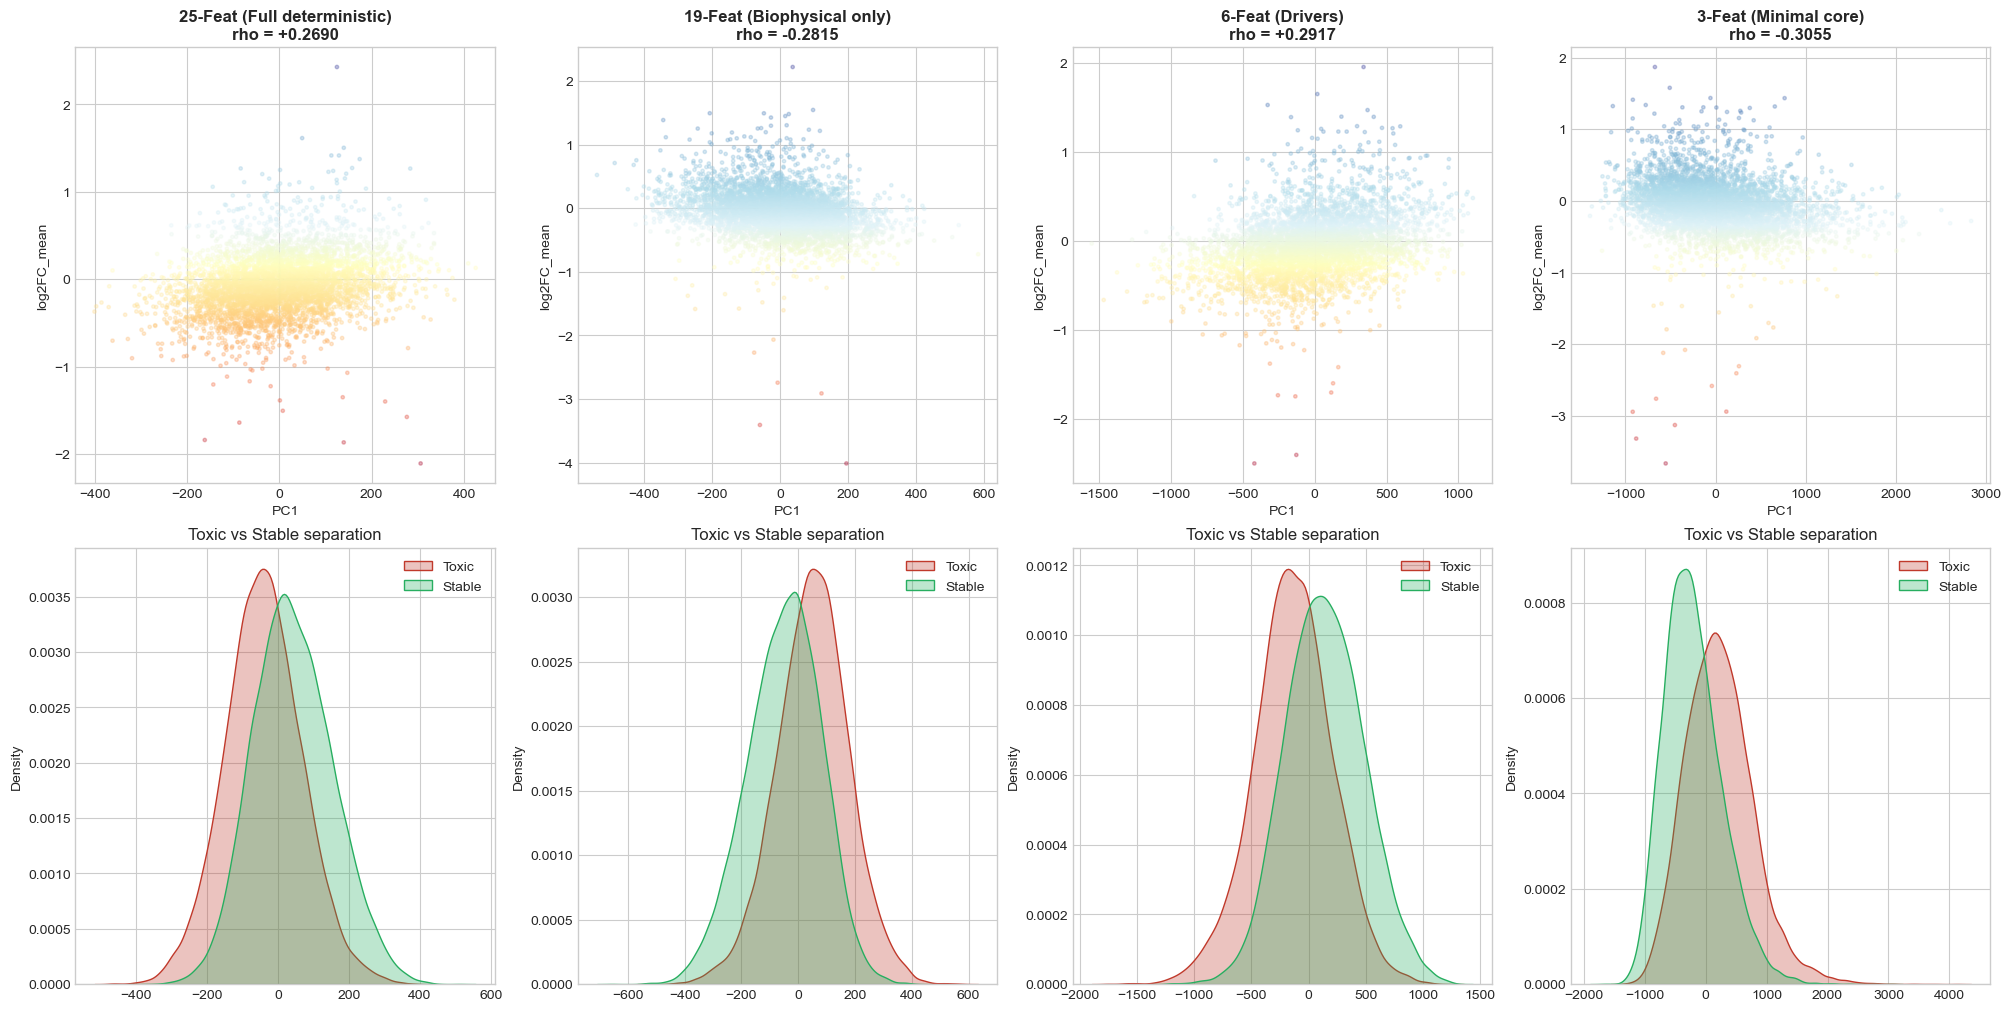


TIER                             | FEATS  | rho (signed)  | CV mean ± std     
-----------------------------------------------------------------------------------------------
25-Feat (Full deterministic)     | 25     | +0.2690      | +0.269 ± 0.004    
19-Feat (Biophysical only)       | 19     | -0.2815      | -0.282 ± 0.004    
6-Feat (Drivers)                 | 6      | +0.2917      | +0.292 ± 0.002    
3-Feat (Minimal core)            | 3      | -0.3055      | -0.306 ± 0.005    
Signed rho — sign-flips between tiers are expected and don't matter for
downstream burden interpretation. Investigate any tier whose sign disagrees
with the rest. The 3-feature minimal tier should outperform the full panel
(replicating v1.5 finding) — if it doesn't, your feature scaling is off.


In [ ]:
# =====================================================================
# @title Section 4, Cell 23: Model Reduction Analysis (v2.1, unsupervised)
# =====================================================================
# Tests how unsupervised PC1 (from a fresh SVD on each tier's feature set)
# correlates with log2FC_mean as we remove features. The full v1.5 finding
# was that the 3-feature core (Max_Homo, Entropy, AT_tract) outperforms
# the full feature panel — adding more features dilutes the signal.
#
# Only deterministic biophysical features are used. Learned features
# (CNN_Score, UMAP coords, PC1) are excluded — including them would be
# circular (they were derived from earlier SVD/CNN fits using the labels).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix

print("--- Model reduction analysis (unsupervised tiers) ---")

# Strictly biophysical / deterministic features; no learned scores.
biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]

features_full     = biophys_all + computed_det
features_hardware = biophys_all
features_drivers  = [f for f in ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
                                  'GC_percent', 'mRNA_Stability'] if f in df_train.columns]
features_minimal  = [f for f in ['Max_Homo', 'Entropy', 'AT_tract'] if f in df_train.columns]

tiers = {
    f'{len(features_full)}-Feat (Full deterministic)': features_full,
    f'{len(features_hardware)}-Feat (Biophysical only)': features_hardware,
    f'{len(features_drivers)}-Feat (Drivers)':           features_drivers,
    f'{len(features_minimal)}-Feat (Minimal core)':      features_minimal,
}

def evaluate_tier(feats, n_cv=5):
    sc = StandardScaler()
    X_mech = sc.fit_transform(df_train[feats])
    sf = X_train_sp.shape[1] / max(1, X_mech.shape[1])
    X_comb = hstack([X_train_sp, csr_matrix(X_mech * sf)])

    svd_full = TruncatedSVD(n_components=2, random_state=42)
    pc1 = svd_full.fit_transform(X_comb)[:, 0]
    rho_full, _ = spearmanr(pc1, df_train['log2FC_mean'])

    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv_rhos = []
    for tr, te in kf.split(X_comb):
        s = TruncatedSVD(n_components=2, random_state=42)
        s.fit(X_comb[tr])
        pc1_te = s.transform(X_comb[te])[:, 0]
        r, _ = spearmanr(pc1_te, df_train['log2FC_mean'].iloc[te])
        cv_rhos.append(r)
    return {
        'n_features': len(feats),
        'rho_full':   rho_full,
        'cv_mean':    float(np.mean(cv_rhos)),
        'cv_std':     float(np.std(cv_rhos)),
        'pc1':        pc1,
    }

results = {}
for label, feats in tiers.items():
    print(f"  Processing {label} ({len(feats)} features)...")
    results[label] = evaluate_tier(feats)

# Plot
n_tiers = len(results)
fig, axes = plt.subplots(2, n_tiers, figsize=(5 * n_tiers, 10), layout='constrained')
plot_rng = np.random.default_rng(42)
for col, (label, r) in enumerate(results.items()):
    samp = plot_rng.choice(len(r['pc1']), size=min(5000, len(r['pc1'])), replace=False)
    ax = axes[0, col]
    ax.scatter(r['pc1'][samp], df_train['log2FC_mean'].iloc[samp],
               c=df_train['log2FC_mean'].iloc[samp], cmap='RdYlBu', s=6, alpha=0.3)
    ax.set_title(f"{label}\nrho = {r['rho_full']:+.4f}", fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('log2FC_mean')

    ax2 = axes[1, col]
    quartiles = pd.qcut(df_train['log2FC_mean'], q=4, labels=['Toxic', 'Q2', 'Q3', 'Stable'])
    for q_l, color in zip(['Toxic', 'Stable'], ['#c0392b', '#27ae60']):
        mask = (quartiles == q_l).values
        sns.kdeplot(r['pc1'][mask], ax=ax2, fill=True, color=color, label=q_l, alpha=0.3)
    ax2.set_title('Toxic vs Stable separation'); ax2.legend()
plt.show()

# Report
print("\n" + "=" * 95)
print(f"{'TIER':<32} | {'FEATS':<6} | {'rho (signed)':<13} | {'CV mean ± std':<18}")
print("-" * 95)
for label, r in results.items():
    cv_str = f"{r['cv_mean']:+.3f} ± {r['cv_std']:.3f}"
    print(f"{label:<32} | {r['n_features']:<6} | {r['rho_full']:+.4f}      | {cv_str:<18}")
print("=" * 95)
print("Signed rho — sign-flips between tiers are expected and don't matter for")
print("downstream burden interpretation. Investigate any tier whose sign disagrees")
print("with the rest. The 3-feature minimal tier should outperform the full panel")
print("(replicating v1.5 finding) — if it doesn't, your feature scaling is off.")

--- Combined validation suite ---

[1/3] Projecting unsupervised tiers onto df_test...
  25-Feat (Full det.): aligned rho on df_test = +0.3601
  25-Feat (Full det.): aligned rho on df_test = +0.3601
  19-Feat (Biophysical): aligned rho on df_test = +0.3699
  19-Feat (Biophysical): aligned rho on df_test = +0.3699
  6-Feat (Drivers): aligned rho on df_test = +0.3741
  6-Feat (Drivers): aligned rho on df_test = +0.3741
  3-Feat (Minimal): aligned rho on df_test = +0.3841
  3-Feat (Minimal): aligned rho on df_test = +0.3841

[2/3] Running validation tests on each predictor...
  validating 25-Feat (Full det.)...
  validating 19-Feat (Biophysical)...
  validating 6-Feat (Drivers)...
  validating 3-Feat (Minimal)...
  validating SUPERVISED STACK (Cell 18)...

[3/3] Comparison table (all predictors evaluated on df_test):

Predictor                                rho               95% CI      R^2   Cohen d   Z null      p_emp
--------------------------------------------------------------------

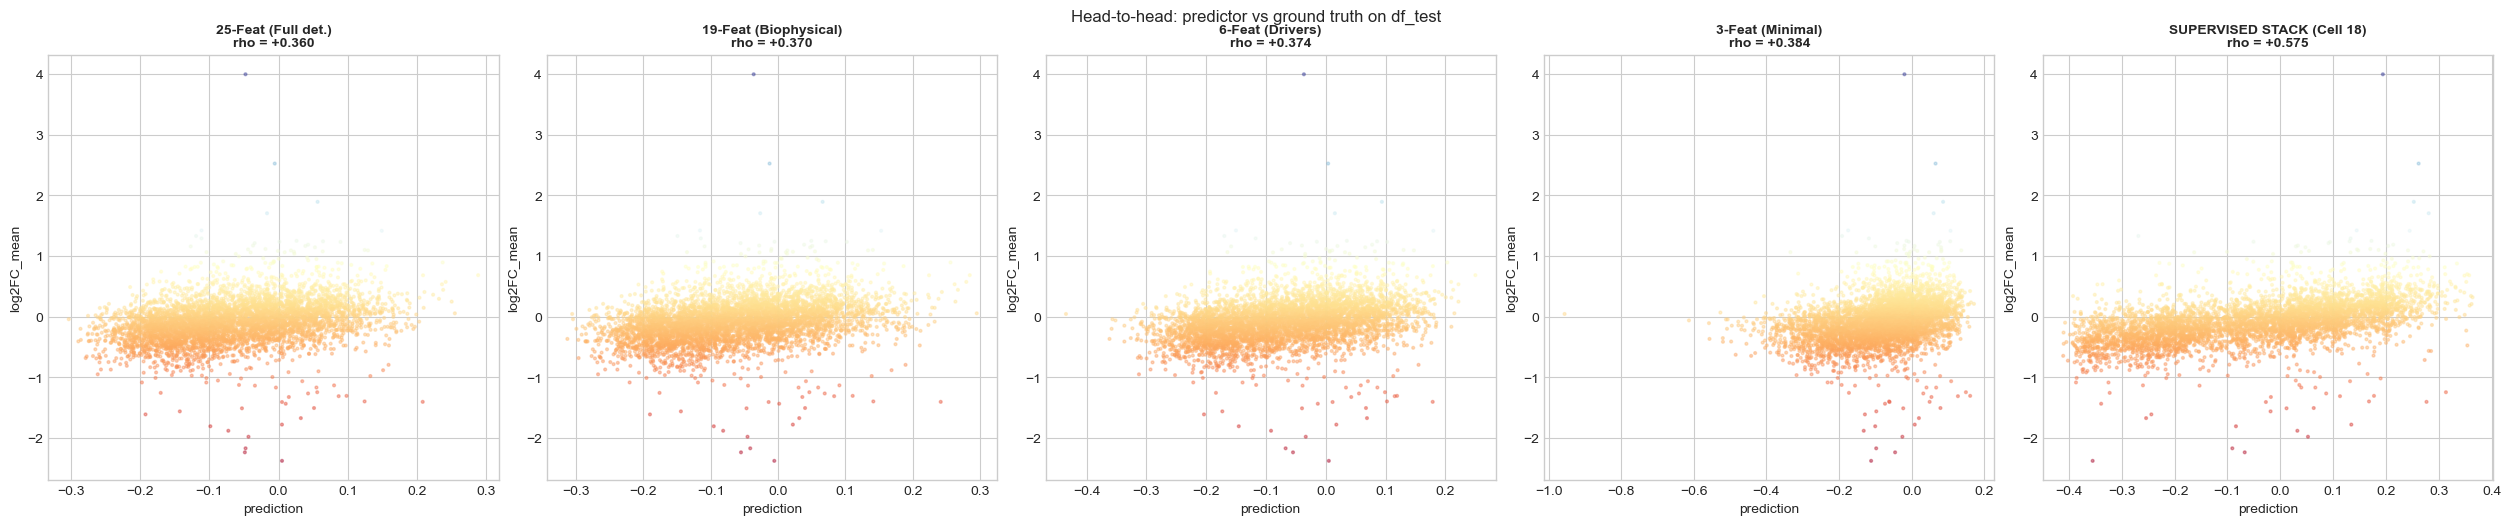


  validation_results dataframe saved to globals.


In [ ]:
# =====================================================================
# @title Cell 24: Combined Validation Suite (supervised + unsupervised tiers)
# =====================================================================
# Runs the full v1.5 Phase 50 validation suite on:
#   - The supervised stack (df_test predictions from Cell 18)
#   - Each unsupervised reduction tier (PC1 from Cell 21, evaluated on df_test)
#
# Reports a unified comparison table at the end so the supervised vs
# unsupervised gap is explicit. This is the cell you cite for the
# "head-to-head: supervised covers X% of variance vs unsupervised" claim.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

print("--- Combined validation suite ---")

# ── 1. PROJECT EACH UNSUPERVISED TIER ONTO df_test ──────────────────────
# Cell 21 fit SVD per tier on df_train. We need PC1 on df_test for the
# same tiers, train-fit-only, so we can compare them to the supervised
# stack on the SAME held-out test set.
print("\n[1/3] Projecting unsupervised tiers onto df_test...")

biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]

tier_features = {
    f'{len(biophys_all + computed_det)}-Feat (Full det.)': biophys_all + computed_det,
    f'{len(biophys_all)}-Feat (Biophysical)':              biophys_all,
    f'{len([f for f in ["Max_Homo","Entropy","AT_tract","HNS_Affinity","GC_percent","mRNA_Stability"] if f in df_train.columns])}-Feat (Drivers)':
        [f for f in ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
                     'GC_percent', 'mRNA_Stability'] if f in df_train.columns],
    f'{len([f for f in ["Max_Homo","Entropy","AT_tract"] if f in df_train.columns])}-Feat (Minimal)':
        [f for f in ['Max_Homo', 'Entropy', 'AT_tract'] if f in df_train.columns],
}

tier_test_pc1 = {}
for label, feats in tier_features.items():
    sc = StandardScaler()
    X_mech_tr = sc.fit_transform(df_train[feats])
    X_mech_te = sc.transform(df_test[feats])
    sf = X_train_sp.shape[1] / max(1, X_mech_tr.shape[1])
    X_comb_tr = hstack([X_train_sp, csr_matrix(X_mech_tr * sf)])
    X_comb_te = hstack([X_test_sp,  csr_matrix(X_mech_te * sf)])
    svd_t = TruncatedSVD(n_components=2, random_state=42)
    svd_t.fit(X_comb_tr)
    pc1_tr = svd_t.transform(X_comb_tr)[:, 0]
    pc1_te = svd_t.transform(X_comb_te)[:, 0]

    # Sign-align using train (so train and test stay consistent)
    rho_align, _ = spearmanr(pc1_tr, df_train['log2FC_mean'])
    if rho_align < 0:
        pc1_tr = -pc1_tr
        pc1_te = -pc1_te

    # Linear projection PC1 -> log2FC scale, fit on train
    slope, intercept = np.polyfit(pc1_tr, df_train['log2FC_mean'].values, 1)
    pred_te = slope * pc1_te + intercept

    tier_test_pc1[label] = pred_te
    rho_check, _ = spearmanr(pred_te, y_te)
    print(f"  {label}: aligned rho on df_test = {rho_check:+.4f}")

# Also include the supervised stack as a "tier" for the comparison table
all_predictors = {**tier_test_pc1, 'SUPERVISED STACK (Cell 18)': df_test['stack_pred'].values}

# ── 2. SHARED VALIDATION FUNCTION ───────────────────────────────────────
print("\n[2/3] Running validation tests on each predictor...")

def validate_predictor(pred, y, name, n_boot=1000, n_perm=1000, rng_seed=42):
    """Returns dict of validation metrics for one predictor on df_test."""
    rng = np.random.default_rng(rng_seed)
    n = len(y)

    rho, rho_p   = spearmanr(pred, y)
    pear, pear_p = pearsonr(pred, y)
    r2  = r2_score(y, pred) if not np.isnan(np.std(pred)) and np.std(pred) > 0 else np.nan
    mae = mean_absolute_error(y, pred)

    # Bootstrap CI on rho
    boot = np.empty(n_boot, dtype=np.float32)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[i], _ = spearmanr(pred[idx], y[idx])
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    # Permutation null
    null = np.empty(n_perm, dtype=np.float32)
    for i in range(n_perm):
        null[i], _ = spearmanr(pred, rng.permutation(y))
    null_mean, null_std = float(null.mean()), float(null.std())
    z = (rho - null_mean) / max(null_std, 1e-9)
    p_emp = float((np.abs(null) >= abs(rho)).mean())

    # Cohen's d on prediction tiers
    top    = pred >= np.quantile(pred, 0.90)
    bottom = pred <= np.quantile(pred, 0.10)
    pooled = np.sqrt((y[top].var(ddof=1) + y[bottom].var(ddof=1)) / 2)
    d = (y[top].mean() - y[bottom].mean()) / max(pooled, 1e-9)

    # Heteroscedasticity
    het, _ = spearmanr(np.abs(y - pred), np.abs(pred)) if r2 != np.nan else (np.nan, np.nan)

    # Calibration slope
    if np.std(pred) > 0:
        slope, intercept = np.polyfit(pred, y, 1)
    else:
        slope, intercept = np.nan, np.nan

    return {
        'name':           name,
        'spearman_rho':   float(rho),
        'rho_p':          float(rho_p),
        'pearson_r':      float(pear),
        'r2':             float(r2),
        'mae':            float(mae),
        'ci_95_lo':       float(ci_lo),
        'ci_95_hi':       float(ci_hi),
        'null_mean':      null_mean,
        'null_std':       null_std,
        'z_score':        float(z),
        'perm_p_emp':     p_emp,
        'cohens_d':       float(d),
        'heteroscedasticity_rho': float(het) if not np.isnan(het) else np.nan,
        'calibration_slope':      float(slope) if not np.isnan(slope) else np.nan,
    }

results = {}
for name, pred in all_predictors.items():
    print(f"  validating {name}...")
    results[name] = validate_predictor(pred, y_te, name)

# ── 3. UNIFIED COMPARISON TABLE ─────────────────────────────────────────
print("\n[3/3] Comparison table (all predictors evaluated on df_test):")

comp_df = pd.DataFrame(results).T
comp_df = comp_df.sort_values('spearman_rho', ascending=False)
print()
print(f"{'Predictor':<35} {'rho':>8} {'95% CI':>20} {'R^2':>8} {'Cohen d':>9} {'Z null':>8} {'p_emp':>10}")
print("-" * 105)
for _, r in comp_df.iterrows():
    ci = f"[{r['ci_95_lo']:+.3f}, {r['ci_95_hi']:+.3f}]"
    print(f"{r['name']:<35} {r['spearman_rho']:>+8.4f} {ci:>20} "
          f"{r['r2']:>+8.4f} {r['cohens_d']:>+9.3f} {r['z_score']:>+8.1f} {r['perm_p_emp']:>10.4f}")

# Head-to-head: supervised vs best unsupervised
sup_rho = results['SUPERVISED STACK (Cell 18)']['spearman_rho']
unsup_rhos = {k: v['spearman_rho'] for k, v in results.items() if k != 'SUPERVISED STACK (Cell 18)'}
best_unsup_name = max(unsup_rhos, key=unsup_rhos.get)
best_unsup_rho = unsup_rhos[best_unsup_name]
coverage = (best_unsup_rho / sup_rho) * 100 if sup_rho > 0 else np.nan

print(f"\n  HEAD-TO-HEAD:")
print(f"    Supervised stack rho:           {sup_rho:+.4f}")
print(f"    Best unsupervised tier rho:     {best_unsup_rho:+.4f}  ({best_unsup_name})")
print(f"    Unsupervised covers {coverage:.0f}% of supervised performance")
print(f"    Gap (Layer 4 contribution):     {sup_rho - best_unsup_rho:+.4f}")

# Replicate-quality ceiling
if 'log2FC_std' in df_test.columns:
    print(f"\n  REPLICATE-QUALITY CEILING:")
    cleanest = df_test['log2FC_std'] <= df_test['log2FC_std'].quantile(0.25)
    sup_clean, _ = spearmanr(df_test.loc[cleanest, 'stack_pred'], y_te[cleanest.values])
    print(f"    Supervised rho on cleanest 25% replicates: {sup_clean:+.4f}")
    print(f"    This is your effective ceiling on this dataset.")

# Optional: scatter plot grid of every predictor
fig, axes = plt.subplots(1, len(all_predictors), figsize=(5 * len(all_predictors), 5),
                         layout='constrained')
plot_rng = np.random.default_rng(42)
samp = plot_rng.choice(len(y_te), size=min(5000, len(y_te)), replace=False)
for ax, (name, pred) in zip(axes, all_predictors.items()):
    ax.scatter(pred[samp], y_te[samp], c=y_te[samp], cmap='RdYlBu', s=4, alpha=0.4)
    rho_p = results[name]['spearman_rho']
    ax.set_title(f"{name}\nrho = {rho_p:+.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('prediction'); ax.set_ylabel('log2FC_mean')
plt.suptitle('Head-to-head: predictor vs ground truth on df_test', y=1.02)
plt.show()

# Persist for downstream
validation_results = comp_df
print("\n  validation_results dataframe saved to globals.")

In [ ]:
# =====================================================================
# @title Cell 24b: Checkpoint SAVE 3 (Run after Cell 24, post-validation)
# =====================================================================
# Full pipeline state: dataframes, base models, meta-regressor, scalers,
# vectorisers, SVD, UMAP, CNN, sparse matrices, validation results.
# Deletes Checkpoint 2 to free disk. Resume here for Oracle (Cell 25).
import os
import joblib
import pandas as pd
from datetime import datetime

print("--- Saving Checkpoint 3 (post-validation, full pipeline state) ---")
os.makedirs("checkpoints", exist_ok=True)

# 1. Delete Checkpoint 2 (now superseded)
sp2_files = ["sp2_df_train.pkl", "sp2_df_test.pkl", "sp2_metadata.pkl"]
for f in sp2_files:
    p = f"checkpoints/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  Deleted superseded SP2 file: {f}")

# 2. DataFrames
print("\n  Saving dataframes...")
df_clean.to_pickle("checkpoints/sp3_df_clean.pkl")
df_train.to_pickle("checkpoints/sp3_df_train.pkl")
df_test.to_pickle("checkpoints/sp3_df_test.pkl")

# 3. Base learners (native formats)
print("  Saving base learners...")
base_models['xgb'].save_model("checkpoints/sp3_final_xgb.json")
base_models['cat'].save_model("checkpoints/sp3_final_cat.cbm")
base_models['ranker'].save_model("checkpoints/sp3_final_rank.json")

# 4. Meta-regressor + scalers + SVD + UMAP
print("  Saving meta-regressor and transformers...")
joblib.dump(stacking,      "checkpoints/sp3_stacking.joblib")
joblib.dump(fitted_scaler, "checkpoints/sp3_fitted_scaler.joblib")
joblib.dump(fitted_vec,    "checkpoints/sp3_fitted_vec.joblib")
joblib.dump(svd,           "checkpoints/sp3_svd.joblib")
if 'reducer' in globals():
    joblib.dump(reducer,   "checkpoints/sp3_umap_reducer.joblib")

# 5. CNN
if 'model_cnn' in globals():
    print("  Saving CNN...")
    model_cnn.save("checkpoints/sp3_model_cnn.keras")

# 6. Sparse matrices
print("  Saving sparse k-mer matrices...")
from scipy.sparse import save_npz
save_npz("checkpoints/sp3_X_train_sp.npz", X_train_sp)
save_npz("checkpoints/sp3_X_test_sp.npz",  X_test_sp)

# 7. Metadata + everything else
print("  Saving metadata bundle...")
metadata = {
    'supervised_features': supervised_features,
    'enriched_features':   enriched_features if 'enriched_features' in globals() else [],
    'SCALER_FEATURES':     list(SCALER_FEATURES) if 'SCALER_FEATURES' in globals() else [],
    'xgb_best_params':     xgb_best_params if 'xgb_best_params' in globals() else None,
    'cat_best_params':     cat_best_params if 'cat_best_params' in globals() else None,
    'oof':                 oof,
    'test_pred':           test_pred,
    'sample_weights':      sample_weights,
    'SCALE_FACTOR':        SCALE_FACTOR if 'SCALE_FACTOR' in globals() else None,
    'validation_results':  validation_results if 'validation_results' in globals() else None,
    'savepoint':           3,
    'saved_at':            datetime.now().isoformat(),
}
joblib.dump(metadata, "checkpoints/sp3_metadata.pkl")

# 8. Report
def get_dir_size_mb(path):
    total = 0
    for dp, _, fns in os.walk(path):
        for f in fns:
            if f.startswith('sp3_'):
                total += os.path.getsize(os.path.join(dp, f))
    return total / (1024 * 1024)

print(f"\n  Checkpoint 3 saved.")
print(f"  Total size: {get_dir_size_mb('checkpoints'):.1f} MB")
print(f"  Saved at:   {metadata['saved_at']}")
print(f"\n  To resume on a future run:")
print(f"    1. Set RESUME = True in Cell 0")
print(f"    2. Run Cell 0 only")
print(f"    3. Jump to Cell 25 (Oracle)")

In [ ]:
# =====================================================================
# @title Cell 25: Predictor — Single-Sequence Inference
# =====================================================================
# @markdown Paste a 172bp DNA sequence below to evaluate it against the population baseline.
# @markdown The models must already be trained in the previous cells.

import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.stats import spearmanr, percentileofscore

# --- SAFETY CHECKS ---
required_vars = ['base_models', 'stacking', 'df_train', 'supervised_features']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing variables: {missing_vars}. Please ensure Cell 19 (Base Learners) and Cell 20 (Ridge Stacker) have been run in this session.")
# ---------------------

# ── ENTRY POINT (TEXTBOX OVERLAY) ───────────────────────────────────────
# Paste your sequence here:
oracle_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG" # @param {type:"string"}

print("--- Predictor: single-sequence inference ---")
print(f"Input sequence length: {len(oracle_seq)} bp")

# ── FEATURE COMPUTATION ─────────────────────────────────────────────────
def featurise_oracle(seq):
    """Compute every active feature for one sequence. Returns a 1-row DataFrame."""
    seq = seq.strip().upper()
    feats = calculate_master_features(seq)

    if 'compute_cai' in globals():            feats['CAI_Score']      = compute_cai(seq)
    if 'initiation_mfe_proxy' in globals():   feats['mRNA_MFE']       = initiation_mfe_proxy(seq)
    if 'scan_direct_repeats' in globals():    feats['Max_Repeat_Len'] = scan_direct_repeats(seq)
    if 'count_codon_stalls' in globals():     feats['Codon_Stalls']   = count_codon_stalls(seq)

    if 'encode_sequences' in globals() and '_hairpin_one' in globals():
        seq_int = encode_sequences(pd.Series([seq]))[0]
        feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))
        feats['HNS_Coverage']   = float(_hns_one(seq_int))

    feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20 + feats.get('Promoter_Str', 0.0) * 30)

    if 'model_cnn' in globals() and 'one_hot_encode' in globals():
        seq_oh = one_hot_encode([seq])
        feats['CNN_Score'] = float(model_cnn.predict(seq_oh, verbose=0)[0, 0])

    if 'reducer' in globals() and 'fitted_scaler' in globals():
        scaler_input_feats = list(fitted_scaler.feature_names_in_)
        bio_only = pd.DataFrame([{f: feats.get(f, 0.0) for f in scaler_input_feats}])
        bio_scaled = fitted_scaler.transform(bio_only[scaler_input_feats])
        umap_coords = reducer.transform(bio_scaled)[0]
        feats['UMAP_1'], feats['UMAP_2'] = float(umap_coords[0]), float(umap_coords[1])

    return pd.DataFrame([feats])

print("  Featurising...")
oracle_features = featurise_oracle(oracle_seq)

missing = [f for f in supervised_features if f not in oracle_features.columns]
if missing:
    for f in missing:
        oracle_features[f] = float(df_train[f].mean()) if f in df_train.columns else 0.0
    print(f"  WARN: filled {len(missing)} missing features from train mean: {missing}")

# ── 1. SUPERVISED STACK PREDICTION ──────────────────────────────────────
print("\n[1/3] Supervised stack prediction...")

X_oracle = oracle_features[supervised_features].values.astype(np.float32)

base_oracle = {
    'xgb':    float(base_models['xgb'].predict(X_oracle)[0]),
    'cat':    float(base_models['cat'].predict(X_oracle)[0]),
    'ranker': float(base_models['ranker'].predict(X_oracle)[0]),
}

oracle_stack = np.array([[base_oracle['xgb'], base_oracle['cat'], base_oracle['ranker']]], dtype=np.float32)
oracle_stack_s = stacking['meta_scaler'].transform(oracle_stack)
sup_pred = float(stacking['meta'].predict(oracle_stack_s)[0])

sup_percentile = percentileofscore(df_train['log2FC_mean'].values, sup_pred, kind='mean')
print(f"  Supervised stack predicted log2FC: {sup_pred:+.4f}")
print(f"  Population percentile: {sup_percentile:.1f}%")

# ── 2. UNSUPERVISED TIER PREDICTIONS ────────────────────────────────────
print("\n[2/3] Unsupervised tier predictions...")

# Safe check to ensure Unsupervised variables exist
if 'tier_features' not in globals() or 'fitted_vec' not in globals():
    print("  SKIPPING: 'tier_features' or 'fitted_vec' not found. Run Unsupervised Cells first if you want these metrics.")
else:
    def project_oracle_onto_tier(seq_features, feats):
        sc = StandardScaler()
        X_mech_tr = sc.fit_transform(df_train[feats])
        X_mech_or = sc.transform(seq_features[feats])

        oracle_kmers = " ".join(
            f"BIN{min(int(i / (len(oracle_seq) / 5)), 4):02d}_{oracle_seq[i:i+4]}"
            for i in range(len(oracle_seq) - 3)
        )
        oracle_sp = fitted_vec.transform([oracle_kmers])

        sf = X_train_sp.shape[1] / max(1, X_mech_tr.shape[1])
        X_comb_tr = hstack([X_train_sp, csr_matrix(X_mech_tr * sf)])
        X_comb_or = hstack([oracle_sp,  csr_matrix(X_mech_or * sf)])

        svd_t = TruncatedSVD(n_components=2, random_state=42)
        svd_t.fit(X_comb_tr)
        pc1_or = float(svd_t.transform(X_comb_or)[0, 0])

        pc1_train = svd_t.transform(X_comb_tr)[:, 0]
        rho_align, _ = spearmanr(pc1_train, df_train['log2FC_mean'])
        if rho_align < 0:
            pc1_or = -pc1_or
            pc1_train = -pc1_train

        slope, intercept = np.polyfit(pc1_train, df_train['log2FC_mean'].values, 1)
        return float(slope * pc1_or + intercept)

    tier_oracle = {}
    for label, feats in tier_features.items():
        pred = project_oracle_onto_tier(oracle_features, feats)
        pct = percentileofscore(df_train['log2FC_mean'].values, pred, kind='mean')
        tier_oracle[label] = {'pred': pred, 'pct': pct}
        print(f"  {label:<25} : log2FC = {pred:+.3f} ({pct:.1f}%)")

# ── 3. PERMUTATION-BASED p-VALUE ────────────────────────────────────────
print("\n[3/3] Permutation p-value (significance vs population)...")

n_perm = 1000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df_train), size=n_perm, replace=False)

train_X = df_train[supervised_features].values[sample_idx].astype(np.float32)
train_base_preds = np.column_stack([
    base_models['xgb'].predict(train_X),
    base_models['cat'].predict(train_X),
    base_models['ranker'].predict(train_X),
])
train_stack_preds = stacking['meta'].predict(stacking['meta_scaler'].transform(train_base_preds))

if sup_pred < df_train['log2FC_mean'].median():
    p_val = float((train_stack_preds <= sup_pred).mean())
    direction = "toxic"
else:
    p_val = float((train_stack_preds >= sup_pred).mean())
    direction = "stable"

# ── REPORT ──────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(" FINAL PREDICTION REPORT")
print("=" * 72)
print(f"  Sequence: {oracle_seq[:50]}...")
print(f"  Result  : {sup_pred:+.4f} log2FC (p = {p_val:.4f})")
print(f"  Verdict : {'SIGNIFICANTLY ' if p_val < 0.05 else ''}{direction.upper()}")
print("=" * 72)

RuntimeError: Missing variables: ['base_models']. Please ensure Cell 19 (Base Learners) and Cell 20 (Ridge Stacker) have been run in this session.